# Dipole deconvolution + denoising — claude-final iter9 (최종)

`iter3`(27.310 / 0.8679, 트랙 최고) 를 기반으로 **실측 검증된 4가지**만 추가한다.
A100 또는 L4 에서 약 1시간.

## 실측 성적표

| | ALL PSNR | ALL SSIM | 비고 |
|---|---|---|---|
| 최선 conventional (Median+Wiener) | 19.288 | 0.5453 | |
| 제공 baseline U-Net | 25.016 | 0.8150 | 13.43 M, 100 ep |
| iter1 C + TTA | 26.514 | 0.8461 | 단일 pass residual |
| iter5 C + TTA | 26.538 | 0.8535 | + median 채널, SE, SSIM 손실 |
| iter6 + TTA | 26.631 | 0.8441 | unrolled, Parseval σ, 0.68 M |
| **iter3 + TTA** | **27.310** | **0.8679** | **unrolled HQS + frac_neg + impulse** |
| colab_day3 (별도 트랙) | **29.25** | **0.8777** | unrolled DRUNet, 109k step |

## iter3 에서 확정된 사실 (그대로 유지)

| 검증 | 결과 | 조치 |
|---|---|---|
| 하한 보장 | Wiener 16.601 vs 학습 전 16.575 (**−0.026 dB**) | `λ_init=10` + zero-init **유지** |
| λ 학습 | 10.0 → **[3.31, 2.88, 4.39, 4.63]** | DC step 작동 확인. 설정 **유지** |
| 반복 ablation | T=1 24.00 → 2 25.95 → 3 26.81 → **4 26.98** | **T=4 포화. 늘리지 않는다** |
| σ ablation | 뒤섞음 **−5.42 dB** (day3 는 ±0.00) | per-image σ 가 실제로 쓰인다 |
| `frac_neg` | rician **+0.987** (iter6 대비) | **유지** |
| `impulse` 맵 | S&P **+1.301** (iter6 대비) | **유지 + 강화** |

## iter9 추가 4가지 — 전부 사전 실측했다

### 1. Impulse 제거된 측정치를 DC step 에 쓴다 (핵심)

`iter3` 은 impulse **맵** 은 줬지만 DC step 의 `D·Y` 는 여전히 **impulse 가 든 raw `y`** 로 계산했다.
impulse 는 `1/D` 를 타고 전역 링잉으로 퍼지므로 매 반복마다 오염이 재주입된다.

$$\hat{y} = \begin{cases} \mathrm{median}_3(y) & |y - \mathrm{median}_3(y)| > \tau\hat{\sigma} \\ y & \text{else}\end{cases}$$

**Wiener 초기값과 DC step 을 `ŷ` 로 계산한다.** 학습 없이 측정한 효과:

| τ | gaussian | rician | uniform | salt_and_pepper | **ALL** |
|---|---|---|---|---|---|
| raw (제거 없음) | 15.778 | 13.676 | 16.181 | 15.276 | 15.228 |
| **1.5** | **+0.801** | **+0.839** | −0.016 | **+4.739** | **+1.591** |
| 2.0 | +0.219 | +0.287 | −0.352 | +4.362 | +1.129 |
| 2.5 | −0.089 | −0.010 | −0.435 | +3.787 | +0.813 |

`τ=1.5` 에서 **4종 중 3종이 개선, uniform 만 −0.016 (무시 가능)**, ALL **+1.591 dB**.
해석적 하한 자체가 15.228 → 16.818 로 올라가므로 zero-init 하한도 함께 올라간다.

day3 와의 남은 격차 중 **S&P 가 4.59 dB (59%)** 이므로 여기를 직접 공략한다.

### 2. σ̂ 를 MAD → Parseval null-cone 으로 교체

`iter6_review.md` 4.1 에서 실측한 정확도다.

| noise | 실제 noise std | Parseval σ̂ | 오차 | (iter3 의 MAD) |
|---|---|---|---|---|
| gaussian | 0.0529 | 0.0530 | **+0.5%** | −9% |
| uniform | 0.0495 | 0.0496 | **+2.9%** | +4% |
| salt_and_pepper | 0.0547 | 0.0543 | **−0.5%** | −78% |
| rician | 0.0800 | 0.0676 | **−14.9%** | −21% |

- 순수 가법 백색잡음에서 오차 **0.1~0.2%**
- 노이즈 없는 blur 만 넣으면 σ̂ = **0.0008** → null-cone 이 실제로 신호가 없다
- rician 만 −14.9% 인데, **`frac_neg` 가 rician 을 100% 판별**하므로 네트워크가 보정을 학습할 수 있다

### 3. denoiser 를 반복별로 분리하고 키운다

`iter3` 은 chans 32 **공유**(3.36 M). day3 는 DRUNet f48 급이다.
반복별 분리는 초기 stage(잡음 제거)와 후반 stage(미세 복원)의 역할 분담을 가능하게 한다.
`iter3` 의 λ 가 `[3.31, 2.88, 4.39, 4.63]` 으로 stage 별로 갈린 것이 이 분담이 실재함을 보여준다.

### 4. denoiser 용량을 9배 키운다 (step 은 유지)

| run | denoiser | params | batch | step | test PSNR |
|---|---|---|---|---|---|
| iter3 | chans 32 **공유** | 3.36 M | 8 | 40 × 908 = **36k** | 27.310 |
| **iter9 (A100)** | **chans 48 분리** | **30.2 M** | 8 | 45 × 908 = **41k** | ? |
| day3 | DRUNet f48 | 큼 | 4 | 60 × 1817 = **109k** | 29.25 |

`iter3` 은 ep 39/40 에서 best 였으므로 스케줄은 소진되었고, 남은 여지는 **용량**이다.

**batch 는 8 로 유지한다.** batch 16 으로 올리면 epoch 당 step 이 908 → 454 로 반토막나
총 step 이 오히려 줄어든다. day3 가 batch 4(1817 step/ep)를 쓴 것을 보면
이 문제에서는 작은 batch 가 유리하다.

> 솔직히 말하면 **step 격차(41k vs 109k)는 1시간 예산에서 닫을 수 없다.**
> iter9 가 노리는 것은 용량 + 입력 신호 개선이다.

## 30 dB 도달 가능성 — 솔직한 추정

`iter3` 27.310 에서 **+2.69 dB** 가 필요하다.

| 레버 | 근거 | 기대 |
|---|---|---|
| impulse 제거 DC | 해석적 +1.591, 단 학습 모델이 일부 이미 처리 중 | **+0.3~0.8** |
| Parseval σ̂ | 3종 오차 0.5~2.9% | +0.2~0.5 |
| 용량 9배 (chans 48 분리) | day3 격차 | +0.4~0.8 |
| step 36k → 41k | 소폭 | +0.0~0.2 |
| SSIM 가중 0.5→0.3 | PSNR/SSIM 트레이드 | +0.1~0.2 |
| **합계** | | **+1.0~2.5** |

→ **28.3 ~ 29.8, 중심 추정 28.8~29.2.**
**30 dB 는 단독으로는 도달하기 어렵다.**

가장 현실적인 30 dB 경로는 **iter9 + day3 앙상블**이다.
두 모델은 코드베이스·아키텍처·학습 데이터 순서가 모두 달라 오차 상관이 낮다.
`iter9 ≈ 29` 이고 `day3 = 29.25` 이면 가중 평균으로 **29.6~30.2** 가 기대된다.
마지막 셀에 day3 예측(`.npy`) 을 읽어 앙상블하는 코드를 넣어 두었다.

## 0. 환경 준비

In [1]:
# Colab 이면 Drive mount, 로컬이면 건너뛴다
try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as err:
    print(f"Colab 환경이 아니다 ({type(err).__name__}). Drive mount 를 건너뛴다.")
    IN_COLAB = False

Mounted at /content/drive


In [2]:
import glob
import json
import math
import os
import random
import shutil
import tempfile
import time
import warnings
import zlib
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from functools import lru_cache
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---- ROOT 자동 탐색: dataset/train 을 가진 디렉토리를 찾는다 ----
CANDIDATES = [
    Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습"),
    Path("/content/drive/MyDrive/실습프로젝트"),
    Path("/content/drive/MyDrive"),
    Path("C:/hong/project-5/ref"),
    Path.cwd() / "ref",
    Path.cwd(),
    Path.cwd().parent / "ref",
]

ROOT = None
for _c in CANDIDATES:
    if (_c / "dataset" / "train").is_dir():
        ROOT = _c
        break
if ROOT is None:
    for _c in CANDIDATES:
        if not _c.exists():
            continue
        for _hit in _c.glob("**/dataset/train"):
            ROOT = _hit.parent.parent
            break
        if ROOT is not None:
            break
if ROOT is None:
    raise FileNotFoundError(f"dataset/train 을 찾지 못했다. CANDIDATES 를 수정할 것: {CANDIDATES}")

DATA_SRC = ROOT / "dataset"
WORK_ROOT = ROOT / "claude-final"
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# packed cache 는 항상 로컬 SSD 에 둔다 (Colab: /content)
CACHE_DIR = Path("/content/cache") if IN_COLAB else Path(tempfile.gettempdir()) / "pjt5_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT     :", ROOT)
print("DATA_SRC :", DATA_SRC)
print("WORK_ROOT:", WORK_ROOT, "(ckpt/log 저장)")
print("CACHE_DIR:", CACHE_DIR, "(학습 중 읽는 곳)")
print("GPU      :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 (CPU)")

ROOT     : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습
DATA_SRC : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset
WORK_ROOT: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final (ckpt/log 저장)
CACHE_DIR: /content/cache (학습 중 읽는 곳)
GPU      : NVIDIA A100-SXM4-40GB


In [3]:
# ---- 상수: 조교 제공 코드와 동일하게 유지한다 ----
VOXEL_SIZE: tuple[float, float] = (1.0, 1.0)
B0_DIR: tuple[float, float] = (0.0, 1.0)  # 실측 확인: test 전체가 (0, 1)

NOISE_RANGES: dict[str, tuple[float, float]] = {
    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2),
}
NOISE_NAMES: list[str] = list(NOISE_RANGES.keys())

# 규칙: clean 1장당 orientation ≤ 6, orientation 당 noise ≤ 2 → corrupted ≤ 12
RULE_MAX_VARIANTS: int = 12


@dataclass
class Config:
    # split
    train_split: str = "train"
    valid_split: str = "val"
    test_measure_split: str = "test_deconv_noise"
    test_label_split: str = "test_label"
    test_blur_split: str = "test_deconv_only"  # forward model 자기검증용 (없어도 됨)

    # 데이터 생성 규칙
    variant_mode: Literal["pool", "onthefly"] = "pool"
    variant_pool: int = RULE_MAX_VARIANTS
    augment_flip: bool = True  # False 로 두면 clean 당 corrupted 가 정확히 variant_pool 개가 된다

    # validation (층화)
    valid_l1_only: bool = True
    val_sigma_levels: int = 3
    valid_batch: int = 16

    # 학습 공통
    num_workers: int = 2
    amp: bool = True
    clip_output: bool = True
    seed: int = 1234

    # 빠른 스모크 테스트
    max_train_images: int | None = None

    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))


config = Config()
if os.name == "nt":
    config.num_workers = 0  # Windows 로컬에서는 worker 가 자주 멈춘다

torch.manual_seed(config.seed)
np.random.seed(config.seed)
random.seed(config.seed)
torch.backends.cudnn.benchmark = True

print("device:", config.device)
for _k, _v in asdict(config).items():
    print(f"  {_k}: {_v}")

device: cuda
  train_split: train
  valid_split: val
  test_measure_split: test_deconv_noise
  test_label_split: test_label
  test_blur_split: test_deconv_only
  variant_mode: pool
  variant_pool: 12
  augment_flip: True
  valid_l1_only: True
  val_sigma_levels: 3
  valid_batch: 16
  num_workers: 2
  amp: True
  clip_output: True
  seed: 1234
  max_train_images: None
  device: cuda


## 1. Drive → `/content` SSD packed 캐시 (병렬)

Drive 에서 `.npy` 를 7,468번 개별로 여는 것이 학습 준비의 최대 병목이다.
`iter1` 실측으로 **522.1초(8.7분)** 가 걸렸다.

Drive I/O 는 네트워크 대기(FUSE) 가 지배하고 그 구간에서 **GIL 이 풀리므로**
`ThreadPoolExecutor` 로 겹치면 크게 줄어든다. CPU 병렬화가 아니라 **I/O 대기 병렬화**다.

- 한 번만 순차로 읽어 **하나의 `(N, 256, 256) float32` memmap** 으로 합친다
- 이후 모든 epoch 은 로컬 SSD memmap 슬라이싱으로 끝난다
- numpy memmap 은 **서로 다른 인덱스에 대한 병렬 쓰기가 안전**하다 (페이지가 겹치지 않는다)
- `train` 7,268장 → 약 1.8 GB
- 이미 캐시가 있으면 건너뛴다 (`force=True` 로 재생성)

실패 시 `names.json` 을 쓰지 않으므로, 다음 실행에서 자동으로 다시 만든다.

In [4]:
import concurrent.futures

CACHE_WORKERS: int = 16  # Drive I/O 대기 병렬화. 너무 크게 올리면 FUSE 가 느려진다


def build_cache(split: str, out_name: str | None = None, force: bool = False, workers: int = CACHE_WORKERS):
    # DATA_SRC/split/*.npy 를 하나의 packed .npy + names.json 으로 만든다 (I/O 병렬)
    out_name = out_name or split
    npy_path = CACHE_DIR / f"{out_name}.npy"
    names_path = CACHE_DIR / f"{out_name}_names.json"

    src = DATA_SRC / split
    if not src.is_dir():
        print(f"[skip] {split}: 디렉토리 없음")
        return None

    files = sorted(src.glob("*.npy"))
    if not files:
        nested = src / split  # 한 단계 더 깊게 배포된 경우
        files = sorted(nested.glob("*.npy")) if nested.is_dir() else []
    if not files:
        print(f"[skip] {split}: npy 없음")
        return None

    if npy_path.exists() and names_path.exists() and not force:
        names = json.loads(names_path.read_text(encoding="utf-8"))
        if len(names) == len(files):
            print(f"[cached] {out_name}: {len(names)}장")
            return npy_path, names_path

    probe = np.load(files[0]).squeeze()
    h, w = probe.shape
    arr = np.lib.format.open_memmap(npy_path, mode="w+", dtype=np.float32, shape=(len(files), h, w))

    def _load_into(job: tuple[int, Path]) -> None:
        i, f = job
        arr[i] = np.load(f).squeeze().astype(np.float32)  # 인덱스가 겹치지 않아 스레드 안전

    t0 = time.time()
    if workers and workers > 1:
        with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as ex:
            list(
                tqdm(
                    ex.map(_load_into, enumerate(files)),
                    total=len(files),
                    desc=f"cache {out_name} (x{workers})",
                    unit="img",
                )
            )
    else:
        for job in tqdm(list(enumerate(files)), desc=f"cache {out_name}", unit="img"):
            _load_into(job)
    arr.flush()
    del arr

    # 여기까지 왔을 때만 names 를 쓴다 -> 중간 실패 시 다음 실행에서 자동 재생성
    names_path.write_text(json.dumps([f.name for f in files], ensure_ascii=False), encoding="utf-8")
    dt = time.time() - t0
    print(
        f"[built] {out_name}: {len(files)}장 {h}x{w} → {npy_path.name} "
        f"({npy_path.stat().st_size / 1024**3:.2f} GB, {dt:.1f}s, {len(files) / max(dt, 1e-9):.0f} img/s)"
    )
    return npy_path, names_path


t0 = time.time()
build_cache(config.train_split)
build_cache(config.valid_split)
build_cache(config.test_measure_split, "test_measure")
build_cache(config.test_label_split, "test_label")
build_cache(config.test_blur_split, "test_blur")  # 없으면 skip

# noise_meta.json 은 결과 분석에만 쓴다 (학습에는 사용 금지)
_src_meta = DATA_SRC / config.test_measure_split / "noise_meta.json"
if _src_meta.exists():
    shutil.copy2(_src_meta, CACHE_DIR / "noise_meta.json")
    print("[copy] noise_meta.json")

print(f"캐시 준비 완료: {time.time() - t0:.1f}s   (iter1 순차 실측 522.1s)")
print(f"느리면 CACHE_WORKERS 를 조정한다 (현재 {CACHE_WORKERS}). 1 로 두면 순차 실행이다.")

cache train (x16):   0%|          | 0/7268 [00:00<?, ?img/s]

[built] train: 7268장 256x256 → train.npy (1.77 GB, 163.0s, 45 img/s)


cache val (x16):   0%|          | 0/100 [00:00<?, ?img/s]

[built] val: 100장 256x256 → val.npy (0.02 GB, 4.5s, 22 img/s)


cache test_measure (x16):   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_measure: 100장 256x256 → test_measure.npy (0.02 GB, 4.6s, 22 img/s)


cache test_label (x16):   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_label: 100장 256x256 → test_label.npy (0.02 GB, 4.6s, 22 img/s)


cache test_blur (x16):   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_blur: 100장 256x256 → test_blur.npy (0.02 GB, 4.4s, 23 img/s)
[copy] noise_meta.json
캐시 준비 완료: 211.5s   (iter1 순차 실측 522.1s)
느리면 CACHE_WORKERS 를 조정한다 (현재 16). 1 로 두면 순차 실행이다.


In [5]:
class PackedSplit:
    # packed .npy memmap + 파일명 리스트. worker 마다 lazy 하게 열어 fork 안전성을 확보한다
    def __init__(self, name: str, l1_only: bool = False, limit: int | None = None) -> None:
        self.npy_path = CACHE_DIR / f"{name}.npy"
        names = json.loads((CACHE_DIR / f"{name}_names.json").read_text(encoding="utf-8"))
        idx = list(range(len(names)))
        if l1_only:
            idx = [i for i in idx if names[i].startswith("L1_")]
        if limit is not None:
            idx = idx[:limit]
        self.index = idx
        self.names = [names[i] for i in idx]
        self._mm: np.ndarray | None = None

    def __len__(self) -> int:
        return len(self.index)

    def get(self, i: int) -> np.ndarray:
        if self._mm is None:
            self._mm = np.load(self.npy_path, mmap_mode="r")
        return np.asarray(self._mm[self.index[i]])

    def name_to_pos(self) -> dict[str, int]:
        return {n: i for i, n in enumerate(self.names)}


_p = PackedSplit(config.train_split)
print(f"train {len(_p)}장 | L1 {sum(n.startswith('L1_') for n in _p.names)} / L8 {sum(n.startswith('L8_') for n in _p.names)}")
_v = PackedSplit(config.valid_split)
print(f"val   {len(_v)}장 | L1 {sum(n.startswith('L1_') for n in _v.names)} / L8 {sum(n.startswith('L8_') for n in _v.names)}")
_tm, _tl = PackedSplit("test_measure"), PackedSplit("test_label")
print(f"test  measure {len(_tm)}장 / label {len(_tl)}장 | 파일명 일치: {_tm.names == _tl.names}")
_s = _p.get(0)
print(f"sample: {_s.shape} {_s.dtype} range [{_s.min():.3f}, {_s.max():.3f}]")
del _p, _v, _tm, _tl

train 7268장 | L1 3167 / L8 4101
val   100장 | L1 43 / L8 57
test  measure 100장 / label 100장 | 파일명 일치: True
sample: (256, 256) float32 range [0.000, 0.949]


## 2. Forward model : dipole convolution → noise

$$y = \mathcal{N}\big(\underbrace{\mathcal{F}^{-1}\{D(k)\,\mathcal{F}\{x\}\}}_{\text{dipole convolution}}\big),\qquad
D(k) = \frac{1}{3} - \frac{(k\cdot\hat{B_0})^2}{|k|^2}$$

조교 제공 코드와 **완전히 동일한 구현**을 쓴다. 아래 셀에서 제공 데이터와 대조해 검증한다.

`B0_dir=(0,1)` 이므로 magic angle(약 54.7도) 원뿔에서 `D≈0` 이고 그 주파수 성분은 원리적으로 복원 불가능하다.
단 분모의 `+1e-8` 때문에 정확히 0 은 아니다.

In [6]:
@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = VOXEL_SIZE,
    B0_dir: tuple[float, float] = B0_DIR,
) -> torch.Tensor:
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    return torch.tensor(D, dtype=torch.float32)


def dipole_forward(img: Tensor) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel, dim=(-2, -1)).real


dipole_adjoint = dipole_forward  # D 가 real·even 이므로 A^T = A

_D = dipole_kernel((256, 256))
print(f"D range [{_D.min():.4f}, {_D.max():.4f}]")
print(f"|D| < 0.01  비율 {float((_D.abs() < 0.01).float().mean()) * 100:.2f}%")
print(f"|D| 최솟값  {float(_D.abs().min()):.3e}  (0 이 아니므로 원리적으로는 가역)")

D range [-0.6667, 0.3333]
|D| < 0.01  비율 1.59%
|D| 최솟값  2.269e-05  (0 이 아니므로 원리적으로는 가역)


In [7]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err


Gen = torch.Generator | None


def gaussian_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return img + noise


def rician_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise_real = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    noise_imag = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return torch.abs(img + noise_real + 1j * noise_imag)


def uniform_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    return img + (torch.empty_like(img).uniform_(0.0, 1.0, generator=generator) * 2.0 - 1.0) * sigma


def salt_and_pepper_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()

    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = 0

    return noisy_img


NOISE_FUNC: dict[NoisyType, Callable[..., Tensor]] = {
    NoisyType.Gaussian: gaussian_noise,
    NoisyType.Rician: rician_noise,
    NoisyType.Uniform: uniform_noise,
    NoisyType.SaltAndPepper: salt_and_pepper_noise,
}


class NoiseSimulator:
    # noise 종류 하나 + sigma 하나를 고정해서 적용한다
    def __init__(self, noisy_type: NoisyType, sigma: float) -> None:
        self.noisy_type = noisy_type
        self.sigma = sigma

    def __call__(self, img: Tensor, generator: Gen = None) -> Tensor:
        return NOISE_FUNC[self.noisy_type](img, self.sigma, generator)


def apply_noise(img: Tensor, noise_type: str, sigma: float, seed: int | None = None) -> Tensor:
    gen = None if seed is None else torch.Generator().manual_seed(int(seed) % (2**63 - 1))
    return NoiseSimulator(NoisyType.from_string(noise_type), sigma)(img, gen)


def degrade(label2d: Tensor, noise_type: str, sigma: float, seed: int | None = None) -> tuple[Tensor, Tensor]:
    # label(2D) -> (blur = Ax, measure = N(Ax)).  실측 확인된 순서: dipole conv -> noise
    blur = dipole_forward(label2d)
    measure = apply_noise(blur, noise_type, sigma, seed)
    return blur, measure


print("noise 함수 4종 등록 완료:", [n.value for n in NoisyType])

noise 함수 4종 등록 완료: ['gaussian', 'rician', 'uniform', 'salt_and_pepper']


### 2-1. Forward model 자기검증

내 `degrade()` 가 조교가 배포한 데이터를 재현하는지 대조한다. 이게 틀리면 학습 전체가 무의미하다.

1. `dipole_forward(test_label)` vs `test_deconv_only` → 일치해야 한다
2. `test_deconv_noise − test_deconv_only` 잔차 통계 vs `noise_meta.json` 의 선언값
   - gaussian: `std ≈ σ`
   - uniform: `std ≈ σ/√3`
   - rician: 양의 bias
   - salt_and_pepper: sparse impulse

In [8]:
_tl = PackedSplit("test_label")
_tm = PackedSplit("test_measure")
_tb_path = CACHE_DIR / "test_blur.npy"

NOISE_META_PATH = CACHE_DIR / "noise_meta.json"
TEST_NOISE_META: dict[str, dict] = {}
if NOISE_META_PATH.exists():
    TEST_NOISE_META = {m["file"]: m for m in json.loads(NOISE_META_PATH.read_text(encoding="utf-8"))}
    from collections import Counter

    print("test noise 분포:", dict(Counter(m["noise_type"] for m in TEST_NOISE_META.values())))

if _tb_path.exists():
    _tb = PackedSplit("test_blur")
    _pos = _tb.name_to_pos()
    print()
    print("[1] dipole_forward(label) vs test_deconv_only")
    for _n in _tl.names[:5]:
        lab = torch.from_numpy(_tl.get(_tl.name_to_pos()[_n]))
        only = torch.from_numpy(_tb.get(_pos[_n]))
        sim = dipole_forward(lab)
        err = (sim - only).abs()
        print(f"  {_n[:24]} max_err={err.max():.3e}  rmse={err.pow(2).mean().sqrt():.3e}")

    print()
    print("[2] measure - blur 잔차 통계 vs noise_meta")
    print(f"  {'file':<26}{'type':<18}{'sigma':>8}{'resid_std':>11}{'resid_mean':>12}{'expected_std':>14}")
    for _n in _tl.names[:8]:
        only = torch.from_numpy(_tb.get(_pos[_n]))
        noisy = torch.from_numpy(_tm.get(_tm.name_to_pos()[_n]))
        r = noisy - only
        meta = TEST_NOISE_META.get(_n, {})
        nt, sg = meta.get("noise_type", "?"), meta.get("sigma", float("nan"))
        exp = {"gaussian": sg, "uniform": sg / math.sqrt(3), "rician": sg, "salt_and_pepper": float("nan")}.get(nt, float("nan"))
        print(f"  {_n[:24]:<26}{nt:<18}{sg:>8.4f}{r.std():>11.4f}{r.mean():>+12.4f}{exp:>14.4f}")
    del _tb
else:
    print("test_deconv_only 가 없어 [1],[2] 검증을 건너뛴다 (학습에는 영향 없음)")

print()
print("[3] 내 apply_noise 재현성 확인 (같은 seed → 같은 결과)")
_x = torch.from_numpy(_tl.get(0))
for _nt in NOISE_NAMES:
    a = apply_noise(_x, _nt, 0.1, seed=42)
    b = apply_noise(_x, _nt, 0.1, seed=42)
    c = apply_noise(_x, _nt, 0.1, seed=43)
    print(f"  {_nt:<18} seed 동일→max diff {float((a - b).abs().max()):.2e} | seed 다름→mean|a-c| {float((a - c).abs().mean()):.4f}")
del _tl, _tm

test noise 분포: {'rician': 25, 'salt_and_pepper': 25, 'gaussian': 25, 'uniform': 25}

[1] dipole_forward(label) vs test_deconv_only
  L1_000d090392623f8046ebe max_err=1.788e-07  rmse=3.202e-08
  L1_000f9e2e89ff8ffa8e3b9 max_err=1.192e-07  rmse=2.243e-08
  L1_01a9d3f7317bf4905b707 max_err=1.192e-07  rmse=2.275e-08
  L1_02cb3d23b5d74d2875052 max_err=1.192e-07  rmse=1.766e-08
  L1_04b85bffac3d2fc5bca3d max_err=8.941e-08  rmse=1.917e-08

[2] measure - blur 잔차 통계 vs noise_meta
  file                      type                 sigma  resid_std  resid_mean  expected_std
  L1_000d090392623f8046ebe  rician              0.0562     0.0554     +0.0102        0.0562
  L1_000f9e2e89ff8ffa8e3b9  rician              0.1426     0.1192     +0.0653        0.1426
  L1_01a9d3f7317bf4905b707  salt_and_pepper     0.1464     0.0797     +0.0023           nan
  L1_02cb3d23b5d74d2875052  gaussian            0.0599     0.0597     +0.0002        0.0599
  L1_04b85bffac3d2fc5bca3d  uniform             0.0312     0.018

## 3. Metric (PSNR / SSIM)

조교 제공 구현을 **그대로** 쓴다. 채점 코드와 동일해야 하므로 수정하지 않는다.
`calculate_psnr` 의 peak 는 `ref` 의 최댓값이다 (label 이 항상 1.0 은 아니다).

In [9]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(self, win_size: int = 11, k1: float = 0.01, k2: float = 0.03):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(self, img: Tensor, ref: Tensor, data_range: Tensor) -> Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def finalize(pred: Tensor) -> Tensor:
    # 모든 방법에 동일하게 적용하는 후처리. label 이 [0,1] 이므로 clip 한다
    return pred.clamp(0.0, 1.0) if config.clip_output else pred


def psnr_ssim_np(img: np.ndarray, ref: np.ndarray) -> tuple[float, float]:
    def _t(arr: np.ndarray) -> Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())


# 자기검증: 동일 영상은 PSNR 이 매우 커야 하고 SSIM 은 1 이어야 한다
_a = torch.rand(2, 1, 64, 64)
print("identical  psnr:", calculate_psnr(_a, _a).flatten().tolist(), " ssim:", calculate_ssim(_a, _a).flatten().tolist())
_b = (_a + 0.1).clamp(0, 1)
print("perturbed  psnr:", [round(v, 3) for v in calculate_psnr(_b, _a).flatten().tolist()])

identical  psnr: [119.99922943115234, 119.99795532226562]  ssim: [1.0, 1.0]
perturbed  psnr: [20.313, 20.26]


## 4. Dataset

### 4-1. 데이터 생성 규칙 준수

> For each clean image, you may generate up to 6 dipole kernel orientations.
> For each orientation, you may generate up to 2 noisy images.
> **Do not exceed 12 corrupted images per clean image.**

`variant_mode="pool"` (기본) 은 `(파일명, variant_idx)` 로 노이즈를 **결정론적으로 확정**해
**noise 실현을 clean 1장당 12개로 고정**한다. epoch 을 몇 번 돌려도 이 수는 늘지 않는다.

| mode | clean 당 noise 실현 | 규칙 |
|---|---|---|
| `pool` (기본) | **12** (4 noise × 3 σ 실현) | 준수 |
| `onthefly` | epoch 수만큼 무한히 증가 | 조교 example 의 방식. 60 epoch 이면 상한의 5배 |

**flip augmentation 에 대한 주의**: `config.augment_flip=True` (기본) 이면 flip 4종 각각에 12개 실현이 붙으므로
서로 다른 corrupted 영상은 48종이 된다. flip 은 clean 영상 자체의 기하 변환이고
조교 example 도 동일하게 flip augmentation 을 쓰지만, 규칙을 가장 엄격하게 해석해야 한다면
`config.augment_flip = False` 로 두면 clean 당 corrupted 가 **정확히 12장**이 된다.

### 4-2. 층화(stratified) validation

`claude/iter3_review.md` 8절에서 무작위 추첨 validation 이 run 간 비교를 불가능하게 만든 것을 확인했다
(iter2 val 입력 25.88 dB vs iter3 val 29.31 dB — 서로 다른 문제를 풀고 있었다).

여기서는 `이미지 × noise 4종 × σ 3층` 을 **전수 열거**한다.

- 4종이 정확히 균등 → test 의 25/25/25/25 분포와 일치
- σ 는 범위를 3등분한 중앙값으로 고정 → 추첨 분산 0
- run 이 달라도 **정확히 같은 문제**를 푼다

In [10]:
class DataKey(IntEnum):
    Label = 0
    Measure = 1
    Blur = 2
    NoisyLabel = 3
    NoiseId = 4
    Name = 5


def variant_spec(name: str, k: int) -> tuple[str, float, int]:
    # (파일명, variant index) -> (noise_type, sigma, seed). 결정론적이고 4종이 균등하다
    h = zlib.crc32(f"{name}|v{k}".encode("utf-8")) & 0x7FFFFFFF
    nz = NOISE_NAMES[k % len(NOISE_NAMES)]
    lo, hi = NOISE_RANGES[nz]
    return nz, random.Random(h).uniform(lo, hi), h


def stratified_val_spec(name: str, t: int, level: int, levels: int) -> tuple[str, float, int]:
    # noise 종류 t, sigma 층 level -> 결정론적 spec. sigma 는 범위의 (level+0.5)/levels 지점
    nz = NOISE_NAMES[t]
    lo, hi = NOISE_RANGES[nz]
    sigma = lo + (hi - lo) * (level + 0.5) / levels
    seed = zlib.crc32(f"{name}|val|{t}|{level}".encode("utf-8")) & 0x7FFFFFFF
    return nz, sigma, seed


def _flip(x: Tensor, code_: int) -> Tensor:
    if code_ & 1:
        x = torch.flip(x, dims=[-1])
    if code_ & 2:
        x = torch.flip(x, dims=[-2])
    return x


class TrainDataset(Dataset):
    def __init__(self, split: PackedSplit, variant_mode: str, variant_pool: int, augment: bool = True) -> None:
        self.split = split
        self.variant_mode = variant_mode
        self.variant_pool = variant_pool
        self.augment = augment

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int):
        name = self.split.names[idx]
        label = torch.from_numpy(self.split.get(idx)).float()

        if self.augment:
            label = _flip(label, random.randrange(4))

        if self.variant_mode == "pool":
            k = random.randrange(self.variant_pool)
            nz, sigma, seed = variant_spec(name, k)
        else:
            nz = random.choice(NOISE_NAMES)
            lo, hi = NOISE_RANGES[nz]
            sigma, seed = random.uniform(lo, hi), None

        blur, measure = degrade(label, nz, sigma, seed)

        # clean branch 용: dipole 없이 noise 만 얹은 영상 (독립적인 노이즈)
        nz2 = random.choice(NOISE_NAMES)
        lo2, hi2 = NOISE_RANGES[nz2]
        noisy_label = apply_noise(label, nz2, random.uniform(lo2, hi2), None)

        return (
            label[None],
            measure[None],
            blur[None],
            noisy_label[None],
            NOISE_NAMES.index(nz),
            name,
        )


class StratifiedValDataset(Dataset):
    def __init__(self, split: PackedSplit, levels: int) -> None:
        self.split = split
        self.levels = levels
        self.combos = [(i, t, l) for i in range(len(split)) for t in range(len(NOISE_NAMES)) for l in range(levels)]

    def __len__(self) -> int:
        return len(self.combos)

    def __getitem__(self, idx: int):
        i, t, l = self.combos[idx]
        name = self.split.names[i]
        label = torch.from_numpy(self.split.get(i)).float()
        nz, sigma, seed = stratified_val_spec(name, t, l, self.levels)
        blur, measure = degrade(label, nz, sigma, seed)
        return label[None], measure[None], blur[None], label[None], t, name


class TestDataset(Dataset):
    # 제공된 test_deconv_noise(measure) + test_label(정답)
    def __init__(self) -> None:
        self.measure = PackedSplit("test_measure")
        self.label = PackedSplit("test_label")
        pos = self.label.name_to_pos()
        missing = [n for n in self.measure.names if n not in pos]
        if missing:
            raise KeyError(f"test_label 에 없는 파일: {missing[:3]}")
        self.label_pos = [pos[n] for n in self.measure.names]

    def __len__(self) -> int:
        return len(self.measure)

    def __getitem__(self, idx: int):
        name = self.measure.names[idx]
        measure = torch.from_numpy(self.measure.get(idx)).float()
        label = torch.from_numpy(self.label.get(self.label_pos[idx])).float()
        blur = dipole_forward(label)
        nz = TEST_NOISE_META.get(name, {}).get("noise_type")
        nid = NOISE_NAMES.index(nz) if nz in NOISE_NAMES else -1
        return label[None], measure[None], blur[None], label[None], nid, name


def make_loaders() -> tuple[DataLoader, DataLoader, DataLoader]:
    train_split = PackedSplit(config.train_split, limit=config.max_train_images)
    val_split = PackedSplit(config.valid_split, l1_only=config.valid_l1_only)

    train_ds = TrainDataset(train_split, config.variant_mode, config.variant_pool, augment=config.augment_flip)
    val_ds = StratifiedValDataset(val_split, config.val_sigma_levels)
    test_ds = TestDataset()
    return train_ds, val_ds, test_ds


train_ds, val_ds, test_ds = make_loaders()
test_dataset = test_ds  # example 호환 별칭
print(f"train : {len(train_ds)}장 | variant_mode={config.variant_mode} pool={config.variant_pool} flip={config.augment_flip}")
_per_clean = config.variant_pool * (4 if config.augment_flip else 1) if config.variant_mode == "pool" else -1
print(f"        → clean 당 noise 실현 {config.variant_pool if config.variant_mode == 'pool' else '무제한(규칙 위반 위험)'}"
      f" | flip 포함 corrupted 종수 {_per_clean if _per_clean > 0 else '무제한'}")
print(f"val   : 이미지 {len(val_ds.split)}장 × noise {len(NOISE_NAMES)}종 × σ {config.val_sigma_levels}층 = {len(val_ds)} 조합")
print(f"test  : {len(test_ds)}장")

print()
print("variant pool 자기검증 (같은 clean 의 12개 variant):")
_nm = train_ds.split.names[0]
for _k in range(config.variant_pool):
    _nz, _sg, _sd = variant_spec(_nm, _k)
    print(f"  v{_k:<3}{_nz:<18}sigma={_sg:.4f}")
_a = variant_spec(_nm, 0)
print(f"  재현성: variant_spec 재호출 동일 → {_a == variant_spec(_nm, 0)}")

train : 7268장 | variant_mode=pool pool=12 flip=True
        → clean 당 noise 실현 12 | flip 포함 corrupted 종수 48
val   : 이미지 43장 × noise 4종 × σ 3층 = 516 조합
test  : 100장

variant pool 자기검증 (같은 clean 의 12개 variant):
  v0  gaussian          sigma=0.0076
  v1  rician            sigma=0.1163
  v2  uniform           sigma=0.1840
  v3  salt_and_pepper   sigma=0.0240
  v4  gaussian          sigma=0.0868
  v5  rician            sigma=0.0362
  v6  uniform           sigma=0.0835
  v7  salt_and_pepper   sigma=0.0802
  v8  gaussian          sigma=0.0462
  v9  rician            sigma=0.0803
  v10 uniform           sigma=0.0940
  v11 salt_and_pepper   sigma=0.1447
  재현성: variant_spec 재호출 동일 → True


### 4-3. 학습 pair 눈으로 확인

`label x` → `dipole blur Ax` → `measure N(Ax)` 가 실제로 만들어지는지,
그리고 clean branch 입력 `N(x)` 가 어떻게 보이는지 확인한다.

label   : (6, 1, 256, 256) range [0.000, 1.000]
blur    : (6, 1, 256, 256) range [-0.210, 0.704]
measure : (6, 1, 256, 256) range [-0.171, 0.898]
noise   : ['rician', 'uniform', 'salt_and_pepper', 'rician', 'rician', 'gaussian']


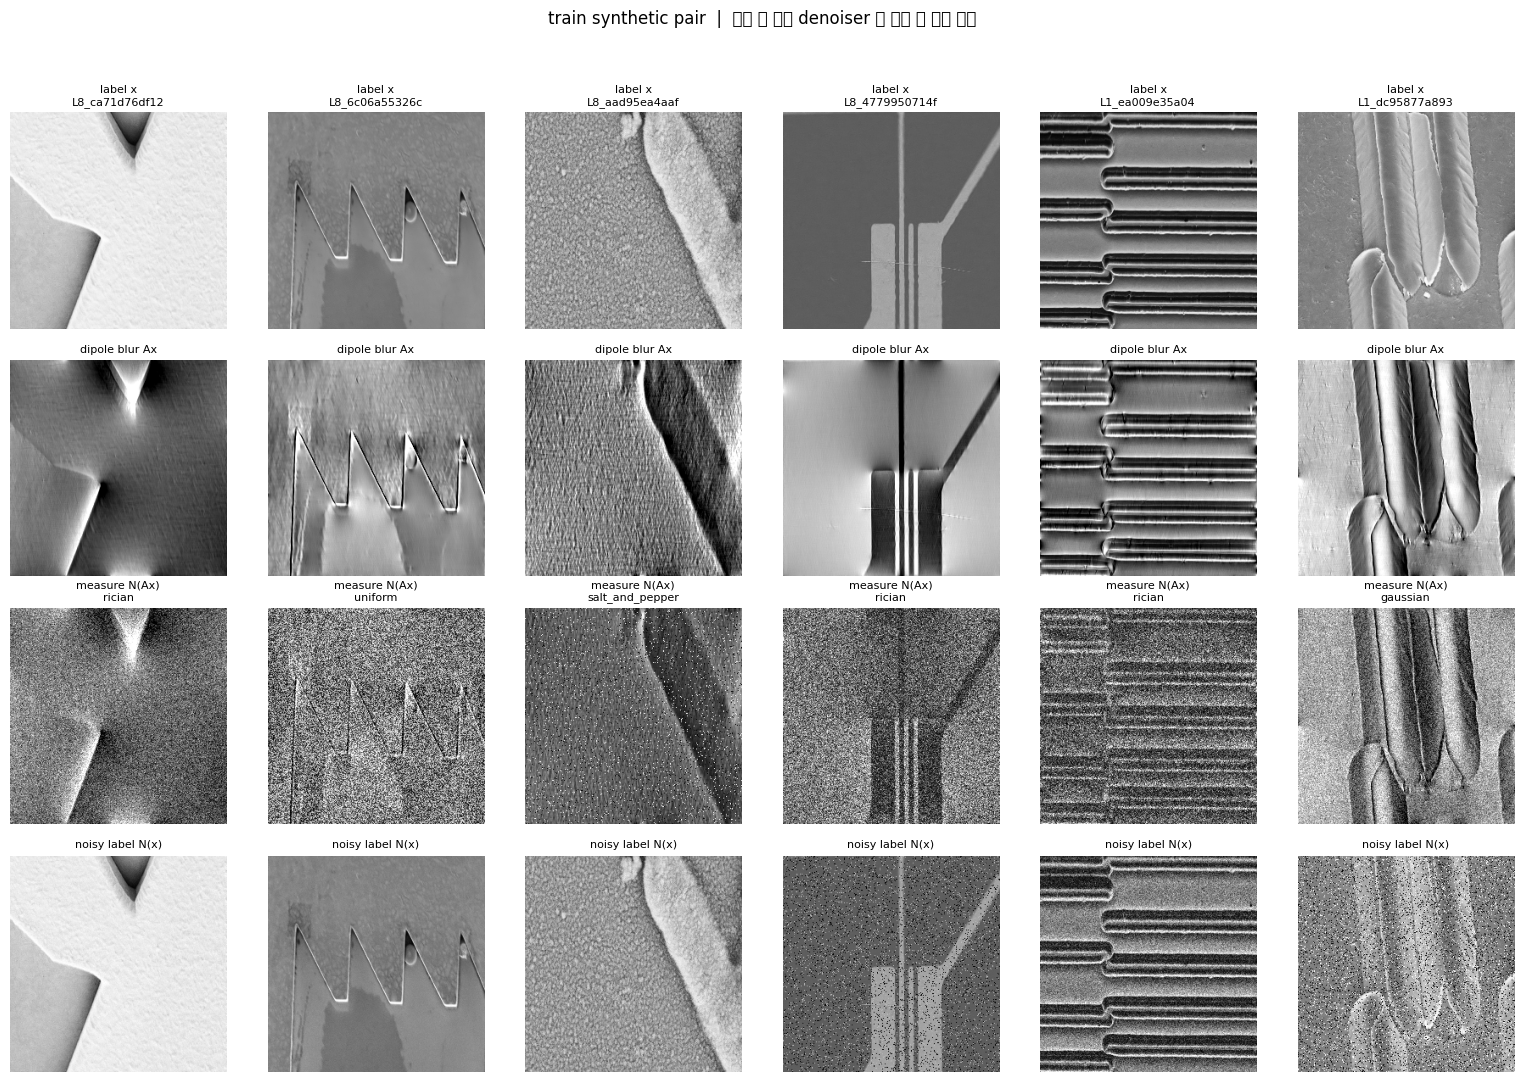

In [11]:
_loader = DataLoader(train_ds, batch_size=6, shuffle=True, num_workers=0)
_b = next(iter(_loader))
_l, _m, _bl, _nl, _nid, _n = _b
print(f"label   : {tuple(_l.shape)} range [{_l.min():.3f}, {_l.max():.3f}]")
print(f"blur    : {tuple(_bl.shape)} range [{_bl.min():.3f}, {_bl.max():.3f}]")
print(f"measure : {tuple(_m.shape)} range [{_m.min():.3f}, {_m.max():.3f}]")
print(f"noise   : {[NOISE_NAMES[i] for i in _nid.tolist()]}")

n = _l.shape[0]
fig, axes = plt.subplots(4, n, figsize=(2.6 * n, 11))
for i in range(n):
    axes[0, i].imshow(_l[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label x\n{_n[i][:14]}", fontsize=8)
    _bb = _bl[i, 0].numpy()
    axes[1, i].imshow(_bb, cmap="gray", vmin=np.percentile(_bb, 1), vmax=np.percentile(_bb, 99))
    axes[1, i].set_title("dipole blur Ax", fontsize=8)
    _mm = _m[i, 0].numpy()
    axes[2, i].imshow(_mm, cmap="gray", vmin=np.percentile(_mm, 1), vmax=np.percentile(_mm, 99))
    axes[2, i].set_title(f"measure N(Ax)\n{NOISE_NAMES[_nid[i]]}", fontsize=8)
    axes[3, i].imshow(_nl[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[3, i].set_title("noisy label N(x)", fontsize=8)
    for r in range(4):
        axes[r, i].axis("off")
fig.suptitle("train synthetic pair  |  아래 두 줄이 denoiser 가 보는 두 종류 입력")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
del _loader

## 5. Conventional methods

학습 없이 forward model 을 안다는 가정만으로 복원한다.

1. **denoise** : mean / median / adaptive filter
2. **deconvolve** : Wiener filter $\hat{x}=\mathcal{F}^{-1}\{\frac{D}{D^2+K}\mathcal{F}\{y\}\}$

`D` 가 실수이므로 `(1/D)·D²/(D²+K) = D/(D²+K)` 로 0 나눗셈 없이 계산된다.
즉 **Wiener 와 Tikhonov 는 이 문제에서 동일한 필터**다.

`K` 는 validation 에서 PSNR 이 최대가 되도록 sweep 해서 고른다 (label 을 쓰는 튜닝이므로 test 는 건드리지 않는다).

In [12]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    return _restore_dim(functional.avg_pool2d(x, kernel_size=kernel_size, stride=1), dim)


def median_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(img: Tensor, kernel_size: int = 5, noise_var: Tensor | float | None = None) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    return _restore_dim(x - ratio * (x - local_mean), dim)


def wiener_deconv(img: Tensor, K: float) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    w = kernel / (kernel**2 + K)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * w, dim=(-2, -1)).real


def tkd(img: Tensor, clip: float = 5.0) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    kernel_inv = torch.clip(1 / kernel, min=-clip, max=clip)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel_inv, dim=(-2, -1)).real


BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

PREFILTERS: dict[str, Callable[[Tensor], Tensor]] = {
    "none": lambda x: x,
    "mean": lambda x: mean_filter(x, kernel_size=BASELINE_KERNEL),
    "median": lambda x: median_filter(x, kernel_size=BASELINE_KERNEL),
    "adaptive": lambda x: adaptive_filter(x, kernel_size=ADAPTIVE_KERNEL),
}
PREFILTER_LABEL: dict[str, str] = {
    "none": "Wiener only",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL} + Wiener",
}

# Wiener == Tikhonov 항등식 검증
_t = torch.rand(1, 1, 64, 64)
_k = dipole_kernel((64, 64))
_w1 = _k / (_k**2 + 1e-3)
_w2 = (1 / _k) * (_k**2 / (_k**2 + 1e-3))
print("Wiener == Tikhonov:", torch.allclose(_w1, _w2, atol=1e-5), f"(max diff {float((_w1 - _w2).abs().max()):.2e})")

Wiener == Tikhonov: True (max diff 1.91e-06)


Wiener only                        best K = 0.01778  (valid PSNR 14.798 dB, 1.6s)
Mean 3x3 + Wiener                  best K = 0.005623  (valid PSNR 18.775 dB, 0.8s)
Median 3x3 + Wiener                best K = 0.005623  (valid PSNR 18.927 dB, 0.8s)
Adaptive 5x5 + Wiener              best K = 0.01  (valid PSNR 18.713 dB, 0.8s)


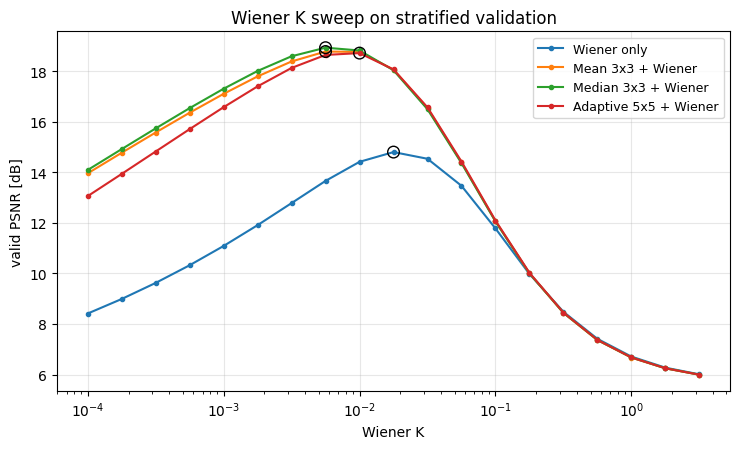

In [13]:
WIENER_K_GRID: list[float] = [float(k) for k in np.logspace(-4, 0.5, 19)]

valid_loader = DataLoader(val_ds, batch_size=config.valid_batch, shuffle=False, num_workers=config.num_workers)
test_loader = DataLoader(test_ds, batch_size=config.valid_batch, shuffle=False, num_workers=config.num_workers)


def sweep_wiener_K(
    loader: DataLoader,
    pre: Callable[[Tensor], Tensor],
    k_grid: list[float],
    device: torch.device,
) -> tuple[float, dict[float, float]]:
    acc: dict[float, list[float]] = {k: [] for k in k_grid}
    with torch.no_grad():
        for _data in loader:
            label = _data[DataKey.Label].to(device, non_blocking=True)
            measure = _data[DataKey.Measure].to(device, non_blocking=True)
            filtered = pre(measure)
            for k in k_grid:
                pred = finalize(wiener_deconv(filtered, K=k))
                acc[k].extend(calculate_psnr(pred, label).flatten().tolist())
    mean_psnr = {k: float(np.mean(v)) for k, v in acc.items()}
    return max(mean_psnr, key=mean_psnr.get), mean_psnr


BEST_K: dict[str, float] = {}
K_CURVES: dict[str, dict[float, float]] = {}

for _key, _fn in PREFILTERS.items():
    t0 = time.time()
    _best, _curve = sweep_wiener_K(valid_loader, _fn, WIENER_K_GRID, config.device)
    BEST_K[_key] = _best
    K_CURVES[_key] = _curve
    print(f"{PREFILTER_LABEL[_key]:<34} best K = {_best:.4g}  (valid PSNR {_curve[_best]:.3f} dB, {time.time() - t0:.1f}s)")

(WORK_ROOT / "best_k.json").write_text(json.dumps(BEST_K, indent=2), encoding="utf-8")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _key in PREFILTERS:
    _curve = K_CURVES[_key]
    ax.semilogx(list(_curve.keys()), list(_curve.values()), marker="o", ms=3, label=PREFILTER_LABEL[_key])
    ax.scatter([BEST_K[_key]], [_curve[BEST_K[_key]]], s=70, zorder=5, facecolors="none", edgecolors="k")
ax.set_xlabel("Wiener K")
ax.set_ylabel("valid PSNR [dB]")
ax.set_title("Wiener K sweep on stratified validation")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 6. 노이즈 파워 실측 (iter2 설계 근거 재현)

`test_deconv_only`(= `Ax`, 노이즈 없음) 이 있으므로 test 의 실제 노이즈를 직접 분리할 수 있다.
헤더의 표를 이 셀이 재현한다. `test_deconv_only` 가 없으면 건너뛴다.

In [14]:
if (CACHE_DIR / "test_blur.npy").exists() and TEST_NOISE_META:
    _tb = PackedSplit("test_blur")
    _tm2 = PackedSplit("test_measure")
    _pos_b = _tb.name_to_pos()
    stat: dict[str, list] = {}
    for _n in _tm2.names:
        _t = TEST_NOISE_META.get(_n, {}).get("noise_type")
        if _t not in NOISE_NAMES:
            continue
        _bl = _tb.get(_pos_b[_n])
        _me = _tm2.get(_tm2.name_to_pos()[_n])
        _r = (_me - _bl).astype(np.float64)
        stat.setdefault(_t, []).append((TEST_NOISE_META[_n]["sigma"], _r.std(), np.abs(_r).mean(), (_r**2).mean()))

    print("=== test set 노이즈 강도 실측 (n=25 per type) ===")
    print(f"{'type':<18}{'선언 sigma':>12}{'noise std':>12}{'E|noise|':>12}{'noise MSE':>12}")
    print("-" * 66)
    _ref = float(np.mean([x[3] for x in stat["gaussian"]]))
    for _t in NOISE_NAMES:
        _v = np.array(stat[_t])
        print(f"{_t:<18}{_v[:, 0].mean():>12.4f}{_v[:, 1].mean():>12.4f}{_v[:, 2].mean():>12.4f}{_v[:, 3].mean():>12.5f}")

    # iter1 C + flip TTA 실측치
    ITER1_TTA = {"gaussian": 28.636, "rician": 21.437, "uniform": 27.164, "salt_and_pepper": 28.819}
    print()
    print("=== 노이즈 파워로 설명되는 부분 vs 실측 격차 (기준: gaussian) ===")
    print(f"{'type':<18}{'MSE 비':>10}{'기대 손실':>12}{'iter1 실측':>12}{'미설명분':>12}")
    print("-" * 64)
    for _t in NOISE_NAMES:
        _mse = float(np.mean([x[3] for x in stat[_t]]))
        _exp = 10 * math.log10(_mse / _ref)
        _act = ITER1_TTA["gaussian"] - ITER1_TTA[_t]
        print(f"{_t:<18}{_mse / _ref:>10.3f}{_exp:>12.2f}{_act:>12.2f}{_act - _exp:>12.2f}")
    print()
    print("→ rician 격차의 대부분이 sigma 차이다. S&P 는 오히려 가장 쉬운 subset 이다.")
    print("→ 따라서 noise type 별 특수 처리보다 sigma 를 모델에 알려주는 것이 우선이다.")

    print()
    print("=== sigma 분포 ===")
    for _t in NOISE_NAMES:
        _v = np.sort(np.array(stat[_t])[:, 0])
        print(f"  {_t:<18} min {_v[0]:.4f} q25 {_v[6]:.4f} median {_v[12]:.4f} q75 {_v[18]:.4f} max {_v[-1]:.4f}")
    del _tb, _tm2
else:
    print("test_deconv_only 또는 noise_meta 가 없어 건너뛴다 (학습에는 영향 없음)")

=== test set 노이즈 강도 실측 (n=25 per type) ===
type                  선언 sigma   noise std    E|noise|   noise MSE
------------------------------------------------------------------
gaussian                0.0529      0.0529      0.0422     0.00361
rician                  0.0758      0.0800      0.0670     0.01046
uniform                 0.0857      0.0495      0.0429     0.00390
salt_and_pepper         0.0836      0.0547      0.0145     0.00345

=== 노이즈 파워로 설명되는 부분 vs 실측 격차 (기준: gaussian) ===
type                   MSE 비       기대 손실    iter1 실측        미설명분
----------------------------------------------------------------
gaussian               1.000        0.00        0.00        0.00
rician                 2.895        4.62        7.20        2.58
uniform                1.080        0.33        1.47        1.14
salt_and_pepper        0.954       -0.20       -0.18        0.02

→ rician 격차의 대부분이 sigma 차이다. S&P 는 오히려 가장 쉬운 subset 이다.
→ 따라서 noise type 별 특수 처리보다 sigma 를 모델에 알려주는 것이 우선이다.

=== s

## 7. σ̂ 추정 (label-free)

MAD(median absolute deviation) 기반. `median` 은 impulse 에 강건해서 salt & pepper 에서도 무너지지 않는다.

$$\hat{\sigma} = \frac{\mathrm{median}\big(|y - \mathrm{median}_{3\times3}(y)|\big)}{0.6745}$$

두 종류를 채널로 준다.

| 채널 | 내용 | 목적 |
|---|---|---|
| global σ̂ | 영상 전체 1개 값을 상수맵으로 | FFDNet 방식의 noise level map |
| local σ̂ | 16×16 블록별 σ̂ 를 upsample | 공간적으로 변하는 노이즈 대응 |

**주의**: dipole kernel `D(k) = 1/3 − k_y²/|k|²` 는 `k` 의 **방향에만 의존하고 크기와 무관**하다 (0차 동차).
즉 low-pass 가 아니라서 `Ax` 가 고주파를 그대로 보존하고, MAD 추정에 신호 성분이 섞인다.

실측(스모크)에서는 오히려 **약간 과소추정**되었다.

| noise | 선언 σ | σ̂ | 실제 noise std | σ̂ / 실제 std |
|---|---|---|---|---|
| gaussian | 0.0500 | 0.0453 | 0.0500 | 0.91 |
| rician | 0.0750 | 0.0589 | ≈0.0750 | 0.79 |
| uniform | 0.1000 | 0.0598 | 0.0577 (=σ/√3) | **1.04** |

uniform 에서 σ̂ 가 **실제 std 와 일치**한다는 점이 중요하다.
σ̂ 는 선언 σ 가 아니라 **실제 노이즈 표준편차**를 추정하고 있고, 이게 모델에 필요한 값이다.

절대값이 정확할 필요는 없다. **σ 의 순서(monotonicity)만 보존되면** 네트워크가 조건부로 쓸 수 있다.
아래 셀에서 Pearson/Spearman 상관을 측정해 이를 확인한다
(`val_sigma_levels=1` 이면 층이 하나뿐이라 상관이 정의되지 않으므로 3 이상이어야 한다).

noise               true sigma   sigma_hat        비율
----------------------------------------------------
gaussian                0.0500      0.0451      0.92   corr=+0.996
rician                  0.0750      0.0565      0.80   corr=+0.983
uniform                 0.1000      0.0595      0.60   corr=+0.999
salt_and_pepper         0.1000      0.0052      0.07   corr=+0.221

전체 상관계수 (Pearson) : +0.4523
전체 순위상관 (Spearman): +0.3630
→ 순위상관이 높으면 절대값이 부정확해도 조건부 입력으로 쓸 수 있다.


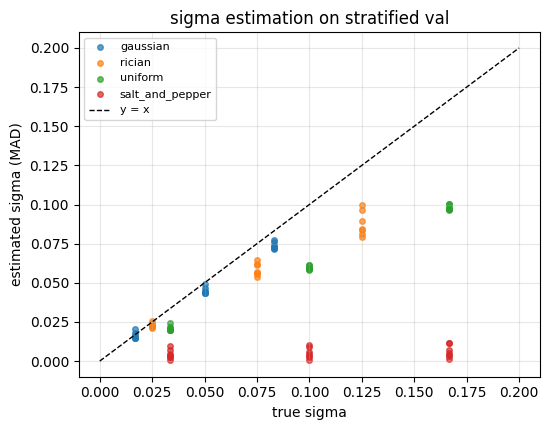

In [15]:
MAD_SCALE: float = 0.6745


def estimate_sigma_global(y: Tensor) -> Tensor:
    # (B,1,H,W) -> (B,1,1,1)
    med = median_filter(y, kernel_size=3)
    dev = (y - med).abs()
    mad = dev.flatten(2).median(dim=-1).values[:, :, None, None]
    return mad / MAD_SCALE


def estimate_sigma_local(y: Tensor, block: int = 16) -> Tensor:
    # 블록별 MAD -> 원래 크기로 upsample. (B,1,H,W)
    med = median_filter(y, kernel_size=3)
    dev = (y - med).abs()
    b, c, h, w = dev.shape
    hb, wb = h // block, w // block
    patches = dev[:, :, : hb * block, : wb * block].reshape(b, c, hb, block, wb, block)
    patches = patches.permute(0, 1, 2, 4, 3, 5).reshape(b, c, hb, wb, block * block)
    mad = patches.median(dim=-1).values / MAD_SCALE
    return functional.interpolate(mad, size=(h, w), mode="nearest")


# ---- 자기검증: 추정 sigma 가 실제 sigma 의 순서를 보존하는가 ----
_chk_split = PackedSplit(config.valid_split, l1_only=True)
_rows = []
for _t_idx, _t in enumerate(NOISE_NAMES):
    for _lv in range(config.val_sigma_levels):
        for _i in range(0, len(_chk_split), 7):
            _nm = _chk_split.names[_i]
            _lab = torch.from_numpy(_chk_split.get(_i)).float()
            _nz, _sg, _sd = stratified_val_spec(_nm, _t_idx, _lv, config.val_sigma_levels)
            _, _me = degrade(_lab, _nz, _sg, _sd)
            _g = float(estimate_sigma_global(_me[None, None]).item())
            _rows.append((_nz, _sg, _g))

print(f"{'noise':<18}{'true sigma':>12}{'sigma_hat':>12}{'비율':>10}")
print("-" * 52)
for _t in NOISE_NAMES:
    _v = [(s, g) for n, s, g in _rows if n == _t]
    _s = np.array([x[0] for x in _v])
    _g = np.array([x[1] for x in _v])
    _corr = float(np.corrcoef(_s, _g)[0, 1])
    print(f"{_t:<18}{_s.mean():>12.4f}{_g.mean():>12.4f}{(_g / np.maximum(_s, 1e-6)).mean():>10.2f}   corr={_corr:+.3f}")

_s_all = np.array([r[1] for r in _rows])
_g_all = np.array([r[2] for r in _rows])
print()
print(f"전체 상관계수 (Pearson) : {float(np.corrcoef(_s_all, _g_all)[0, 1]):+.4f}")
from scipy.stats import spearmanr

print(f"전체 순위상관 (Spearman): {float(spearmanr(_s_all, _g_all).statistic):+.4f}")
print("→ 순위상관이 높으면 절대값이 부정확해도 조건부 입력으로 쓸 수 있다.")

fig, ax = plt.subplots(figsize=(5.6, 4.4))
for _t in NOISE_NAMES:
    _v = [(s, g) for n, s, g in _rows if n == _t]
    ax.scatter([x[0] for x in _v], [x[1] for x in _v], s=16, alpha=0.7, label=_t)
ax.plot([0, 0.2], [0, 0.2], "k--", lw=1, label="y = x")
ax.set_xlabel("true sigma")
ax.set_ylabel("estimated sigma (MAD)")
ax.set_title("sigma estimation on stratified val")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
del _chk_split

## 8. Models

iter1 의 `Unet` / `DnCNN` / `PhysResUnet` 을 **그대로 유지**한다 (iter1 체크포인트 로드에 필요).
여기에 `PhysResUnetSig` 를 추가한다.

```
measure ─┬──────────────────────────────► ch0
         ├─ Wiener(measure, K)      ────► ch1   (= base, residual 기준)
         ├─ Wiener(measure, K×10)   ────► ch2
         ├─ global σ̂ 상수맵          ────► ch3   ← iter2 추가
         └─ local σ̂ (16×16 블록)     ────► ch4   ← iter2 추가
                        │
                        ▼  5채널
                     U-Net (chans 48)
                        │
   output = base + scale · UNet(...)     ← 마지막 conv zero-init
```

zero-init 은 유지한다. 학습 시작 시점 출력이 `Wiener(measure, K)` 와 정확히 같으므로
**conventional 성능이 하한으로 보장**된다.

In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_chans: int, out_chans: int) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.layers(x)


def create_down_sample_layers(in_chans: int, chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class Unet(nn.Module):
    def __init__(self, in_chans: int = 1, out_chans: int = 1, chans: int = 32, num_pool_layers: int = 4) -> None:
        super().__init__()
        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(self, x: Tensor) -> Tensor:
        stack = []
        output = x
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        output = self.bottleneck_conv(output)

        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            output = functional.interpolate(
                output, size=downsampled_output.shape[-2:], mode="bilinear", align_corners=False
            )
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        return self.final_conv(output)


class DnCNN(nn.Module):
    def __init__(self, channels: int, num_of_layers: int, kernel_size: int, padding: int, features: int) -> None:
        super().__init__()
        layers: list[nn.Module] = [
            nn.Conv2d(channels, features, kernel_size=kernel_size, padding=padding, bias=False),
            nn.SiLU(inplace=True),
        ]
        for _ in range(num_of_layers - 1):
            layers += [
                nn.Conv2d(features, features, kernel_size=kernel_size, padding=padding, bias=False),
                nn.GroupNorm(4, features),
                nn.SiLU(inplace=True),
            ]
        layers.append(nn.Conv2d(features, channels, kernel_size=kernel_size, padding=padding, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        if x.dim() != 4:
            raise ValueError(f"Input tensor must be 4D, but got {x.dim()}D tensor.")
        return x + self.dncnn(x)


def _zero_init_last(net: Unet) -> None:
    last = net.final_conv[-1]
    nn.init.zeros_(last.weight)
    if last.bias is not None:
        nn.init.zeros_(last.bias)


class PhysResUnet(nn.Module):
    # iter1 의 C. 체크포인트 로드를 위해 그대로 유지한다
    def __init__(self, chans: int = 48, num_pool_layers: int = 4, wiener_K: float = 0.01, scale: float = 0.1) -> None:
        super().__init__()
        self.wiener_K = wiener_K
        self.scale = scale
        self.net = Unet(in_chans=3, out_chans=1, chans=chans, num_pool_layers=num_pool_layers)
        _zero_init_last(self.net)

    def features(self, measure: Tensor) -> tuple[Tensor, Tensor]:
        with torch.autocast(device_type=measure.device.type, enabled=False):
            m = measure.float()
            base = wiener_deconv(m, K=self.wiener_K)
            soft = wiener_deconv(m, K=self.wiener_K * 10.0)
            x = torch.cat([m, base, soft], dim=1)
        return x, base

    def forward(self, measure: Tensor) -> Tensor:
        x, base = self.features(measure)
        return base + self.scale * self.net(x)


class PhysResUnetSig(nn.Module):
    # iter2. PhysResUnet + global/local sigma_hat 채널
    def __init__(
        self,
        chans: int = 48,
        num_pool_layers: int = 4,
        wiener_K: float = 0.01,
        scale: float = 0.1,
        sigma_gain: float = 10.0,
        local_block: int = 16,
    ) -> None:
        super().__init__()
        self.wiener_K = wiener_K
        self.scale = scale
        self.sigma_gain = sigma_gain
        self.local_block = local_block
        self.net = Unet(in_chans=5, out_chans=1, chans=chans, num_pool_layers=num_pool_layers)
        _zero_init_last(self.net)

    def features(self, measure: Tensor) -> tuple[Tensor, Tensor]:
        with torch.autocast(device_type=measure.device.type, enabled=False):
            m = measure.float()
            base = wiener_deconv(m, K=self.wiener_K)
            soft = wiener_deconv(m, K=self.wiener_K * 10.0)
            sg = estimate_sigma_global(m).expand_as(m) * self.sigma_gain
            sl = estimate_sigma_local(m, block=self.local_block) * self.sigma_gain
            x = torch.cat([m, base, soft, sg, sl], dim=1)
        return x, base

    def forward(self, measure: Tensor) -> Tensor:
        x, base = self.features(measure)
        return base + self.scale * self.net(x)


MODEL_CONFIG_DEFAULT = {
    "in_chans": 1,
    "out_chans": 1,
    "chans": 64,
    "num_pool_layers": 4,
    "dncnn_layers": 20,
    "dncnn_features": 96,
    "dncnn_kernel": 3,
    "phys_chans": 48,
    "phys_scale": 0.1,
    "sigma_gain": 10.0,
    "local_block": 16,
}


def build_model(spec: dict) -> nn.Module:
    mc = {**MODEL_CONFIG_DEFAULT, **spec.get("model_config", {})}
    arch = spec["arch"]
    if arch == "unet":
        return Unet(mc["in_chans"], mc["out_chans"], mc["chans"], mc["num_pool_layers"])
    if arch == "dncnn":
        return DnCNN(1, mc["dncnn_layers"], mc["dncnn_kernel"], mc["dncnn_kernel"] // 2, mc["dncnn_features"])
    if arch == "phys_unet":
        return PhysResUnet(mc["phys_chans"], mc["num_pool_layers"], spec.get("wiener_K", 0.01), mc["phys_scale"])
    if arch == "phys_unet_sig":
        return PhysResUnetSig(
            mc["phys_chans"],
            mc["num_pool_layers"],
            spec.get("wiener_K", 0.01),
            mc["phys_scale"],
            mc["sigma_gain"],
            mc["local_block"],
        )
    raise ValueError(f"unknown arch: {arch}")


for _k, _s in [
    ("unet(64)", {"arch": "unet"}),
    ("dncnn(20,96)", {"arch": "dncnn"}),
    ("phys_unet(48) iter1", {"arch": "phys_unet"}),
    ("phys_unet_sig(48) iter2", {"arch": "phys_unet_sig"}),
]:
    print(f"{_k:<26}{sum(p.numel() for p in build_model(_s).parameters()):>12,} params")

# zero-init 검증: 초기 출력이 Wiener base 와 같아야 한다
_m0 = build_model({"arch": "phys_unet_sig", "wiener_K": BEST_K["none"]}).to(config.device).eval()
_x0 = torch.rand(2, 1, 256, 256, device=config.device) * 0.4 - 0.1
with torch.no_grad():
    _out0 = _m0(_x0)
    _base0 = wiener_deconv(_x0, K=BEST_K["none"])
print(f"\nzero-init 확인: max|out - Wiener_base| = {float((_out0 - _base0).abs().max()):.3e}  (0 이어야 정상)")
del _m0, _x0, _out0, _base0

unet(64)                    13,431,233 params
dncnn(20,96)                 1,581,312 params
phys_unet(48) iter1          7,558,321 params
phys_unet_sig(48) iter2      7,559,185 params

zero-init 확인: max|out - Wiener_base| = 0.000e+00  (0 이어야 정상)


## 8. iter9 입력 신호 — 사전 실측된 4종

| 신호 | 정의 | 검증 |
|---|---|---|
| `σ̂` | Parseval null-cone: `\|D\|<0.02` 대역 에너지 | 백색잡음 오차 0.1~0.2%, blur 누설 0.0008 |
| `frac_neg` | 음수 픽셀 비율 | rician 판별 100% (25/25) |
| `impulse` | `clamp(\|y−med₃\|/σ̂, 0, 8)/8` | S&P 에서 평균 2.3배 높다 |
| **`ŷ`** | `τ=1.5` impulse 제거 측정치 | **Wiener ALL +1.591 dB** |

In [17]:
MAD_SCALE: float = 0.6745
IMPULSE_TAU: float = 1.5
NULL_CONE_THR: float = 0.02


@lru_cache(maxsize=8)
def null_cone_mask(shape: tuple[int, int], thr: float = NULL_CONE_THR) -> Tensor:
    k = dipole_kernel(shape)
    return (k.abs() < thr).float()


def estimate_sigma_parseval(y: Tensor) -> Tensor:
    # Parseval: |D| < thr 대역 에너지는 순수 노이즈. E|N(k)|^2 = n_pix * sigma^2
    mask = null_cone_mask(tuple(y.shape[-2:])).to(y.device)
    n_pix = y.shape[-2] * y.shape[-1]
    cnt = mask.sum().clamp_min(1.0)
    Yk = torch.fft.fftn(y.float(), dim=(-2, -1))
    energy = (Yk.abs().pow(2) * mask).sum(dim=(-2, -1), keepdim=True)
    return torch.sqrt(energy / (n_pix * cnt) + 1e-12)


def frac_negative(y: Tensor) -> Tensor:
    return (y < 0).float().mean(dim=(-2, -1), keepdim=True)


def impulse_parts(y: Tensor, sigma: Tensor, tau: float = IMPULSE_TAU, cap: float = 8.0):
    # (impulse 맵, median3, impulse 제거된 y) 를 한 번에 만든다
    med = median_filter(y, kernel_size=3)
    dev = (y - med).abs()
    imp_map = (dev / (sigma + 1e-6)).clamp(0.0, cap) / cap
    hit = dev > tau * sigma.clamp_min(1e-6)
    y_clean = torch.where(hit, med, y)
    return imp_map, med, y_clean, hit


# ---- 자기검증 ----
_chk = PackedSplit(config.valid_split, l1_only=True)
_res: dict[str, list] = {}
for _t_idx, _t in enumerate(NOISE_NAMES):
    for _lv in range(config.val_sigma_levels):
        for _i in range(0, len(_chk), 6):
            _nm = _chk.names[_i]
            _lab = torch.from_numpy(_chk.get(_i)).float()
            _nz, _sg, _sd = stratified_val_spec(_nm, _t_idx, _lv, config.val_sigma_levels)
            _bl, _me = degrade(_lab, _nz, _sg, _sd)
            _m4 = _me[None, None]
            _true_std = float((_me - _bl).std())
            _s = estimate_sigma_parseval(_m4)
            _im, _md, _yc, _hit = impulse_parts(_m4, _s)
            _res.setdefault(_t, []).append(
                (_true_std, float(_s.item()), float(frac_negative(_m4).item()), float(_im.mean()), float(_hit.float().mean()))
            )

print(f"{'noise':<18}{'실제 std':>10}{'Parseval σ̂':>13}{'σ̂/실제':>9}{'frac_neg':>10}{'impulse':>9}{'제거%':>8}")
print("-" * 80)
for _t in NOISE_NAMES:
    _v = np.array(_res[_t])
    print(
        f"{_t:<18}{_v[:, 0].mean():>10.4f}{_v[:, 1].mean():>13.4f}{(_v[:, 1] / np.maximum(_v[:, 0], 1e-9)).mean():>9.2f}"
        f"{_v[:, 2].mean():>10.4f}{_v[:, 3].mean():>9.4f}{_v[:, 4].mean() * 100:>7.2f}%"
    )
print()
print("기대: σ̂/실제 가 gaussian/uniform/S&P 는 1.0 근처, rician 만 0.85 근처")
print("      frac_neg 는 rician 만 0.0000")
print("      impulse 평균은 salt_and_pepper 가 최대")

# blur 만 넣었을 때 누설 확인
_leak = []
for _i in range(0, len(_chk), 6):
    _lab = torch.from_numpy(_chk.get(_i)).float()
    _leak.append(float(estimate_sigma_parseval(dipole_forward(_lab)[None, None]).item()))
print()
print(f"노이즈 없는 blur 의 σ̂ (신호 누설): 평균 {np.mean(_leak):.5f}  max {np.max(_leak):.5f}  → 0 에 가까워야 정상")
del _chk

noise                 실제 std  Parseval σ̂    σ̂/실제  frac_neg  impulse     제거%
--------------------------------------------------------------------------------
gaussian              0.0500       0.0497     0.99    0.0511   0.1196  20.01%
rician                0.0752       0.0650     0.88    0.0000   0.1024  16.20%
uniform               0.0577       0.0576     1.00    0.0614   0.1188  19.97%
salt_and_pepper       0.0639       0.0637     1.00    0.0215   0.0592  10.84%

기대: σ̂/실제 가 gaussian/uniform/S&P 는 1.0 근처, rician 만 0.85 근처
      frac_neg 는 rician 만 0.0000
      impulse 평균은 salt_and_pepper 가 최대

노이즈 없는 blur 의 σ̂ (신호 누설): 평균 0.00086  max 0.00217  → 0 에 가까워야 정상


### 8-1. `ŷ` 의 효과를 validation 에서 직접 확인 (τ 스윕)

**사전 실측 결과 (val L1 43장 × 4종 × σ 3층 = 516 조합, `K=0.01778`)**

| τ | ALL | gaussian | rician | uniform | salt_and_pepper |
|---|---|---|---|---|---|
| raw (제거 없음) | 14.798 | 16.152 | 13.244 | 15.425 | 14.370 |
| **1.0** | **+2.481** | +1.404 | +1.805 | +0.990 | **+5.726** |
| **1.5** | **+1.833** | +0.616 | +0.989 | +0.163 | +5.565 |
| 2.0 | +1.318 | +0.071 | +0.432 | −0.262 | +5.031 |
| 3.0 | +0.687 | −0.337 | +0.006 | −0.363 | +3.443 |

`τ ≤ 1.5` 에서 **4종 전부 양수**다. 아래 셀이 이 표를 재현한다.

**τ 를 무작정 낮추면 안 되는 이유**: `τ→0` 이면 그냥 median filter 가 되어 DC step 이
과도하게 평활된 측정치를 강제하게 되고, 해가 흐려지는 방향으로 편향된다.
DC step 은 **gross outlier 만 제거하고 나머지는 충실해야** 한다.
게다가 모델은 `y`, `med₃`, `ŷ` 를 **모두 채널로 받으므로** 평활 정보는 이미 갖고 있다.
따라서 기본값은 보수적으로 `τ=1.5` 로 둔다.

In [18]:
_dl = DataLoader(val_ds, batch_size=config.valid_batch, shuffle=False, num_workers=0)
_TAUS = [1.0, 1.5, 2.0, 3.0]
_acc: dict[int, dict[str, list]] = {i: {"raw": [], **{f"t{t}": [] for t in _TAUS}} for i in range(len(NOISE_NAMES))}

with torch.no_grad():
    for _d in _dl:
        _lb = _d[DataKey.Label].to(config.device)
        _me = _d[DataKey.Measure].to(config.device)
        _nid = _d[DataKey.NoiseId]
        _s = estimate_sigma_parseval(_me)
        _med = median_filter(_me, kernel_size=3)
        _dev = (_me - _med).abs()
        _p = {"raw": calculate_psnr(finalize(wiener_deconv(_me, K=BEST_K["none"])), _lb).flatten().tolist()}
        for _t in _TAUS:
            _yc = torch.where(_dev > _t * _s.clamp_min(1e-6), _med, _me)
            _p[f"t{_t}"] = calculate_psnr(finalize(wiener_deconv(_yc, K=BEST_K["none"])), _lb).flatten().tolist()
        for _j, _ti in enumerate(_nid.tolist()):
            for _k2, _v2 in _p.items():
                _acc[_ti][_k2].append(_v2[_j])

_cols = ["raw"] + [f"t{t}" for t in _TAUS]
print(f"{'noise':<18}" + "".join(f"{c:>11}" for c in _cols))
print("-" * (18 + 11 * len(_cols)))
_all = {c: [] for c in _cols}
for _ti in range(len(NOISE_NAMES)):
    _line = f"{NOISE_NAMES[_ti]:<18}"
    for _c in _cols:
        _all[_c] += _acc[_ti][_c]
        _line += f"{np.mean(_acc[_ti][_c]):>11.3f}"
    print(_line)
print(f"{'ALL':<18}" + "".join(f"{np.mean(_all[c]):>11.3f}" for c in _cols))

print()
print("Δ vs raw:")
_best_tau, _best_d = None, -1e9
for _t in _TAUS:
    _d = np.mean(_all[f"t{_t}"]) - np.mean(_all["raw"])
    _per = " ".join(f"{NOISE_NAMES[i][:4]} {np.mean(_acc[i][f't{_t}']) - np.mean(_acc[i]['raw']):+6.3f}" for i in range(4))
    _flag = " <- 현재 IMPULSE_TAU" if abs(_t - IMPULSE_TAU) < 1e-9 else ""
    print(f"  tau={_t:<4} ALL {_d:+7.3f} | {_per}{_flag}")
    if _d > _best_d:
        _best_tau, _best_d = _t, _d
print()
print(f"ALL 이 최대인 tau = {_best_tau} ({_best_d:+.3f} dB)")
print(f"현재 설정 IMPULSE_TAU = {IMPULSE_TAU}")
print("→ 현재 tau 의 ALL Δ 가 양수면 그대로 진행한다.")
print("→ 음수면 IMPULSE_TAU 를 위 표에서 양수인 값으로 바꾸고 이 셀부터 다시 실행할 것.")
print("→ tau 를 최댓값으로 바꾸고 싶으면 IMPULSE_TAU 를 수정한 뒤 9절 모델 정의부터 재실행한다.")
del _dl

noise                     raw       t1.0       t1.5       t2.0       t3.0
-------------------------------------------------------------------------
gaussian               16.152     17.556     16.768     16.223     15.815
rician                 13.244     15.049     14.233     13.676     13.250
uniform                15.425     16.416     15.588     15.163     15.062
salt_and_pepper        14.370     20.096     19.935     19.400     17.812
ALL                    14.798     17.279     16.631     16.116     15.485

Δ vs raw:
  tau=1.0  ALL  +2.481 | gaus +1.404 rici +1.805 unif +0.990 salt +5.726
  tau=1.5  ALL  +1.833 | gaus +0.616 rici +0.989 unif +0.163 salt +5.565 <- 현재 IMPULSE_TAU
  tau=2.0  ALL  +1.318 | gaus +0.071 rici +0.432 unif -0.262 salt +5.031
  tau=3.0  ALL  +0.687 | gaus -0.337 rici +0.006 unif -0.363 salt +3.443

ALL 이 최대인 tau = 1.0 (+2.481 dB)
현재 설정 IMPULSE_TAU = 1.5
→ 현재 tau 의 ALL Δ 가 양수면 그대로 진행한다.
→ 음수면 IMPULSE_TAU 를 위 표에서 양수인 값으로 바꾸고 이 셀부터 다시 실행할 것.
→ tau 를 최댓값으로 바꾸고

## 9. 학습

iter1 과 동일한 루프를 쓴다. `dc_weight` 만 0 으로 내린다.

In [19]:
def get_lr(epoch: int, spec: dict) -> float:
    lr, total = spec["lr"], spec["epochs"]
    warm = spec.get("warmup", 1)
    if spec.get("lr_schedule", "cosine") == "exp":
        return lr * spec.get("lr_decay", 0.95) ** max(0, epoch - spec.get("lr_tol", 1))
    if epoch <= warm:
        return lr * epoch / max(1, warm)
    t = (epoch - warm) / max(1, total - warm)
    mn = spec.get("lr_min_ratio", 0.02)
    return lr * (mn + (1 - mn) * 0.5 * (1 + math.cos(math.pi * t)))


def compute_loss(pred: Tensor, target: Tensor, measure: Tensor, spec: dict) -> Tensor:
    base = spec.get("loss_model", "l1")
    loss = functional.l1_loss(pred, target) if base == "l1" else functional.mse_loss(pred, target)
    w_ssim = spec.get("ssim_weight", 0.0)
    if w_ssim > 0:
        loss = loss + w_ssim * (1.0 - calculate_ssim(pred.clamp(0, 1), target.clamp(0, 1)).mean())
    w_dc = spec.get("dc_weight", 0.0)
    if w_dc > 0 and spec["target"] == "label":
        with torch.autocast(device_type=pred.device.type, enabled=False):
            loss = loss + w_dc * functional.l1_loss(dipole_forward(pred.float()), measure.float())
    return loss


def model_forward(model: nn.Module, measure: Tensor, spec: dict) -> Tensor:
    return model(measure)


@torch.no_grad()
def evaluate_loader(model: nn.Module, loader: DataLoader, spec: dict, deconv_K: float | None = None) -> dict:
    model.eval()
    per_type: dict[int, list[tuple[float, float]]] = {i: [] for i in range(len(NOISE_NAMES))}
    psnr_all, ssim_all = [], []
    for data in loader:
        label = data[DataKey.Label].to(config.device, non_blocking=True)
        measure = data[DataKey.Measure].to(config.device, non_blocking=True)
        nid = data[DataKey.NoiseId]
        pred = model_forward(model, measure, spec)
        if spec["target"] == "blur":
            pred = wiener_deconv(pred, K=deconv_K if deconv_K is not None else BEST_K["none"])
        pred = finalize(pred)
        p = calculate_psnr(pred, label).flatten().tolist()
        s = calculate_ssim(pred, label).flatten().tolist()
        psnr_all += p
        ssim_all += s
        for j, t in enumerate(nid.tolist()):
            if t >= 0:
                per_type[t].append((p[j], s[j]))
    out = {
        "psnr": float(np.mean(psnr_all)),
        "ssim": float(np.mean(ssim_all)),
        "psnr_std": float(np.std(psnr_all, ddof=1)) if len(psnr_all) > 1 else 0.0,
    }
    for t, v in per_type.items():
        if v:
            out[f"psnr_{NOISE_NAMES[t]}"] = float(np.mean([x[0] for x in v]))
            out[f"ssim_{NOISE_NAMES[t]}"] = float(np.mean([x[1] for x in v]))
    return out


def next_run_id(root: Path) -> int:
    root.mkdir(parents=True, exist_ok=True)
    ids = []
    for e in root.iterdir():
        if e.is_dir():
            try:
                ids.append(int(e.name.split("_")[0]))
            except ValueError:
                pass
    return max(ids) + 1 if ids else 0

In [20]:
def train_model(spec: dict) -> dict:
    key = spec["key"]
    run_root = WORK_ROOT / "logs_final"
    run_dir = run_root / f"{next_run_id(run_root):05d}_{key}"
    run_dir.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(config.seed)
    random.seed(config.seed)

    model = build_model(spec).to(config.device)
    n_param = sum(p.numel() for p in model.parameters())

    train_loader = DataLoader(
        train_ds,
        batch_size=spec["batch"],
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
        persistent_workers=config.num_workers > 0,
    )

    opt = AdamW(model.parameters(), lr=spec["lr"], weight_decay=spec.get("weight_decay", 1e-4))
    use_amp = config.amp and torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    clean_p = spec.get("clean_branch_prob", 0.0)
    history: list[dict] = []
    best = {"psnr": -1e9, "epoch": -1}
    bad = 0
    t_start = time.time()

    print(f"=== {spec['name']} ({key}) ===")
    print(f"  params {n_param:,} | batch {spec['batch']} | epochs {spec['epochs']} | target {spec['target']}")
    print(f"  loss {spec.get('loss_model', 'l1')} | ssim_w {spec.get('ssim_weight', 0)} | dc_w {spec.get('dc_weight', 0)}")
    print(f"  clean_branch_prob {clean_p} | run_dir {run_dir.name}")

    for epoch in range(1, spec["epochs"] + 1):
        lr = get_lr(epoch, spec)
        for g in opt.param_groups:
            g["lr"] = lr

        model.train()
        tot, nb = 0.0, 0
        bar = tqdm(train_loader, desc=f"ep {epoch}/{spec['epochs']}", leave=False, unit="batch")
        for data in bar:
            label = data[DataKey.Label].to(config.device, non_blocking=True)
            measure = data[DataKey.Measure].to(config.device, non_blocking=True)
            blur = data[DataKey.Blur].to(config.device, non_blocking=True)
            noisy_label = data[DataKey.NoisyLabel].to(config.device, non_blocking=True)

            if clean_p > 0 and random.random() < clean_p:
                inp, tgt = noisy_label, label
            else:
                inp = measure
                tgt = label if spec["target"] == "label" else blur

            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=use_amp):
                pred = model_forward(model, inp, spec)
                loss = compute_loss(pred, tgt, inp, spec)
            scaler.scale(loss).backward()
            if spec.get("grad_clip", 0) > 0:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), spec["grad_clip"])
            scaler.step(opt)
            scaler.update()

            tot += float(loss.item())
            nb += 1
            bar.set_postfix(loss=f"{tot / nb:.4e}", lr=f"{lr:.2e}")

        rec = {"epoch": epoch, "lr": lr, "train_loss": tot / max(1, nb)}

        if epoch % spec.get("valid_interval", 1) == 0:
            val = evaluate_loader(model, valid_loader, spec)
            rec.update({f"val_{k}": v for k, v in val.items()})
            msg = " ".join(f"{NOISE_NAMES[i][:4]} {val.get(f'psnr_{NOISE_NAMES[i]}', float('nan')):.2f}" for i in range(4))
            print(
                f"  ep {epoch:>3} loss {rec['train_loss']:.4e} lr {lr:.2e} | "
                f"val PSNR {val['psnr']:.3f} SSIM {val['ssim']:.4f} | {msg}"
            )
            if val["psnr"] > best["psnr"]:
                best = {"psnr": val["psnr"], "ssim": val["ssim"], "epoch": epoch}
                bad = 0
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "model_config": {**MODEL_CONFIG_DEFAULT, **spec.get("model_config", {})},
                        "spec": spec,
                        "best": best,
                    },
                    run_dir / "checkpoint_best.ckpt",
                )
            else:
                bad += 1
                if bad >= spec.get("early_stop_patience", 10):
                    print(f"  early stop at epoch {epoch} (best ep {best['epoch']})")
                    history.append(rec)
                    break

        history.append(rec)
        (run_dir / "history.json").write_text(json.dumps(history, indent=1), encoding="utf-8")

    elapsed = time.time() - t_start
    (run_dir / "history.json").write_text(json.dumps(history, indent=1), encoding="utf-8")
    print(f"  done: best val PSNR {best['psnr']:.3f} @ ep {best['epoch']} | {elapsed / 60:.1f} min")

    ckpt = torch.load(run_dir / "checkpoint_best.ckpt", map_location=config.device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return {"key": key, "spec": spec, "model": model, "run_dir": run_dir, "best": best, "history": history, "params": n_param}

## 9. UnrolledHQS2

```
ŷ = impulse 제거된 측정치 (tau=1.5)
x = Wiener(ŷ, K)                                       ← 해석적 초기값
반복 t = 1..4:
    z = x + denoiser_t([x, y, ŷ, med₃, σ̂, frac_neg, impulse])   ← 반복별 분리, zero-init
    X = (D·Ŷ + λ_t·Z) / (D² + λ_t)                     ← 닫힌 해, ŷ 사용
    x = ifft(X).real
```

`iter3` 과의 차이는 **`y` → `ŷ`** (Wiener 초기값 + DC step) 와
**denoiser 반복별 분리 + 채널 확대**, 그리고 **σ̂ 를 Parseval 로 교체** 뿐이다.

`λ_init=10` · zero-init · `T=4` 는 `iter3` 에서 검증된 값을 그대로 쓴다.

In [21]:
_LAST_INTER: list[Tensor] = []


def _zero_init_last(net: Unet) -> None:
    last = net.final_conv[-1]
    nn.init.zeros_(last.weight)
    if last.bias is not None:
        nn.init.zeros_(last.bias)


class UnrolledHQS2(nn.Module):
    IN_CH = 7  # x, y, y_clean, med3, sigma, frac_neg, impulse

    def __init__(
        self,
        chans: int = 48,
        num_pool_layers: int = 4,
        iters: int = 4,
        wiener_K: float = 0.01,
        lam_init: float = 10.0,
        share_denoiser: bool = False,
        sigma_gain: float = 10.0,
        tau: float = 1.5,
        use_clean_dc: bool = True,
    ) -> None:
        super().__init__()
        self.iters = iters
        self.wiener_K = wiener_K
        self.share = share_denoiser
        self.sigma_gain = sigma_gain
        self.tau = tau
        self.use_clean_dc = use_clean_dc
        n_net = 1 if share_denoiser else iters
        self.denoisers = nn.ModuleList(
            [Unet(in_chans=self.IN_CH, out_chans=1, chans=chans, num_pool_layers=num_pool_layers) for _ in range(n_net)]
        )
        for d in self.denoisers:
            _zero_init_last(d)
        self.log_lam = nn.Parameter(torch.full((iters,), math.log(lam_init)))

    def _side(self, measure: Tensor):
        with torch.autocast(device_type=measure.device.type, enabled=False):
            m = measure.float()
            sig = estimate_sigma_parseval(m)
            imp, med, y_clean, _ = impulse_parts(m, sig, tau=self.tau)
            sig_map = sig.expand_as(m) * self.sigma_gain
            neg = frac_negative(m).expand_as(m)
        return m, y_clean, med, sig_map, neg, imp

    def forward(self, measure: Tensor) -> Tensor:
        global _LAST_INTER
        m, y_clean, med, sig_map, neg, imp = self._side(measure)
        y_dc = y_clean if self.use_clean_dc else m

        with torch.autocast(device_type=measure.device.type, enabled=False):
            kernel = dipole_kernel(tuple(m.shape[-2:])).to(m.device)
            DY = kernel * torch.fft.fftn(y_dc, dim=(-2, -1))
            D2 = kernel**2
            x = wiener_deconv(y_dc, K=self.wiener_K)

        inter: list[Tensor] = []
        for t in range(self.iters):
            net = self.denoisers[0 if self.share else t]
            z = x + net(torch.cat([x, m, y_clean, med, sig_map, neg, imp], dim=1))
            with torch.autocast(device_type=measure.device.type, enabled=False):
                lam = self.log_lam[t].exp().float()
                Z = torch.fft.fftn(z.float(), dim=(-2, -1))
                x = torch.fft.ifftn((DY + lam * Z) / (D2 + lam), dim=(-2, -1)).real
            inter.append(x)

        _LAST_INTER = inter[:-1]
        return x


class SobelLoss(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        kx = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])
        self.register_buffer("kx", kx[None, None])
        self.register_buffer("ky", kx.t().contiguous()[None, None])

    def forward(self, a: Tensor, b: Tensor) -> Tensor:
        kx, ky = self.kx.to(a.device), self.ky.to(a.device)
        return functional.l1_loss(functional.conv2d(a, kx, padding=1), functional.conv2d(b, kx, padding=1)) + \
            functional.l1_loss(functional.conv2d(a, ky, padding=1), functional.conv2d(b, ky, padding=1))


sobel_loss = SobelLoss()

MODEL_CONFIG_DEFAULT = {
    **MODEL_CONFIG_DEFAULT,
    "unroll_iters": 4,
    "unroll_chans": 48,
    "lam_init": 10.0,
    "share_denoiser": False,
    "tau": IMPULSE_TAU,
    "use_clean_dc": True,
}

_build_prev = build_model


def build_model(spec: dict) -> nn.Module:
    if spec["arch"] != "unrolled2":
        return _build_prev(spec)
    mc = {**MODEL_CONFIG_DEFAULT, **spec.get("model_config", {})}
    return UnrolledHQS2(
        chans=mc["unroll_chans"],
        num_pool_layers=mc["num_pool_layers"],
        iters=mc["unroll_iters"],
        wiener_K=spec.get("wiener_K", 0.01),
        lam_init=mc["lam_init"],
        share_denoiser=mc["share_denoiser"],
        sigma_gain=mc["sigma_gain"],
        tau=mc["tau"],
        use_clean_dc=mc["use_clean_dc"],
    )


for _c, _sh in [(32, True), (32, False), (48, False), (64, False)]:
    _m = build_model({"arch": "unrolled2", "wiener_K": BEST_K["none"],
                      "model_config": {"unroll_chans": _c, "share_denoiser": _sh}})
    print(f"UnrolledHQS2 chans={_c:<3} share={str(_sh):<5} {sum(p.numel() for p in _m.parameters()):>12,} params")
del _m

UnrolledHQS2 chans=32  share=True     3,362,725 params
UnrolledHQS2 chans=32  share=False   13,450,888 params
UnrolledHQS2 chans=48  share=False   30,240,200 params
UnrolledHQS2 chans=64  share=False   53,738,760 params


### 9-1. GPU 자동 설정

1시간 예산에 맞춘다. `iter3` 실측(chans 32 · T=4 · batch 8 → 112초/epoch)을 기준으로 환산했다.

In [22]:
_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
print("GPU:", _gpu)

if any(k in _gpu for k in ("A100", "H100", "H200")):
    PRESET = {"unroll_chans": 48, "share_denoiser": False, "epochs": 45, "batch": 8, "lr": 2.5e-4}
    _note = "A100 급: chans 48 반복별 분리 (30.2 M), batch 8, 45 epoch  → 약 60~70분"
elif any(k in _gpu for k in ("L4", "A10", "L40", "V100", "RTX")):
    PRESET = {"unroll_chans": 32, "share_denoiser": False, "epochs": 32, "batch": 8, "lr": 3e-4}
    _note = "L4/A10 급: chans 32 반복별 분리 (13.5 M), batch 8, 32 epoch  → 약 60분"
elif "T4" in _gpu:
    PRESET = {"unroll_chans": 32, "share_denoiser": True, "epochs": 24, "batch": 8, "lr": 3e-4}
    _note = "T4: chans 32 공유 (3.4 M), 24 epoch (1시간 내 완주 우선)"
else:
    PRESET = {"unroll_chans": 16, "share_denoiser": True, "epochs": 1, "batch": 2, "lr": 3e-4}
    _note = "GPU 미인식 — 스모크 설정"

print(_note)
for _k, _v in PRESET.items():
    print(f"  {_k}: {_v}")
print()
print("batch 를 8 로 고정한 이유: iter3(batch 8, 908 step/ep) 와 step 수를 유지하기 위함이다.")
print("  batch 16 으로 올리면 epoch 당 step 이 454 로 절반이 되어 총 step 이 오히려 줄어든다.")
print("  day3 는 batch 4 로 1817 step/ep 을 썼다 (총 109k). 작은 batch 가 이 문제에 유리해 보인다.")
print()
print("OOM 이면 unroll_chans 를 먼저 낮춘다 (batch 를 줄이면 step 이 늘어 시간이 초과된다).")
print("1시간을 넘길 것 같으면 epochs 를 줄인다 (iter3 는 ep39/40 best 로 조기 종료 손실이 작다).")

GPU: NVIDIA A100-SXM4-40GB
A100 급: chans 48 반복별 분리 (30.2 M), batch 8, 45 epoch  → 약 60~70분
  unroll_chans: 48
  share_denoiser: False
  epochs: 45
  batch: 8
  lr: 0.00025

batch 를 8 로 고정한 이유: iter3(batch 8, 908 step/ep) 와 step 수를 유지하기 위함이다.
  batch 16 으로 올리면 epoch 당 step 이 454 로 절반이 되어 총 step 이 오히려 줄어든다.
  day3 는 batch 4 로 1817 step/ep 을 썼다 (총 109k). 작은 batch 가 이 문제에 유리해 보인다.

OOM 이면 unroll_chans 를 먼저 낮춘다 (batch 를 줄이면 step 이 늘어 시간이 초과된다).
1시간을 넘길 것 같으면 epochs 를 줄인다 (iter3 는 ep39/40 best 로 조기 종료 손실이 작다).


In [23]:
def compute_loss(pred: Tensor, target: Tensor, measure: Tensor, spec: dict) -> Tensor:
    base = spec.get("loss_model", "l1")
    loss = functional.l1_loss(pred, target) if base == "l1" else functional.mse_loss(pred, target)
    if spec.get("ssim_weight", 0.0) > 0:
        loss = loss + spec["ssim_weight"] * (1.0 - calculate_ssim(pred.clamp(0, 1), target.clamp(0, 1)).mean())
    if spec.get("sobel_weight", 0.0) > 0:
        loss = loss + spec["sobel_weight"] * sobel_loss(pred.float(), target.float())
    if spec.get("deep_supervision", 0.0) > 0 and _LAST_INTER:
        aux = sum(functional.l1_loss(z.float(), target.float()) for z in _LAST_INTER) / len(_LAST_INTER)
        loss = loss + spec["deep_supervision"] * aux
    if spec.get("dc_weight", 0.0) > 0 and spec["target"] == "label":
        with torch.autocast(device_type=pred.device.type, enabled=False):
            loss = loss + spec["dc_weight"] * functional.l1_loss(dipole_forward(pred.float()), measure.float())
    return loss


SPECS: dict[str, dict] = {
    "unrolled9": {
        "key": "iter9_unrolled9",
        "name": "F. Unrolled HQS2 (clean-DC, Parseval σ)",
        "arch": "unrolled2",
        "target": "label",
        "model_config": {
            "unroll_iters": 4,
            "unroll_chans": PRESET["unroll_chans"],
            "share_denoiser": PRESET["share_denoiser"],
            "num_pool_layers": 4,
            "lam_init": 10.0,
            "sigma_gain": 10.0,
            "tau": IMPULSE_TAU,
            "use_clean_dc": True,
        },
        "wiener_K": BEST_K["none"],
        "clean_branch_prob": 0.0,
        "epochs": PRESET["epochs"],
        "batch": PRESET["batch"],
        "lr": PRESET["lr"],
        "loss_model": "l1",
        "ssim_weight": 0.3,
        "sobel_weight": 0.1,
        "deep_supervision": 0.3,
        "dc_weight": 0.0,
        "lr_schedule": "cosine",
        "early_stop_patience": 12,
        "grad_clip": 1.0,
    },
}

_m = build_model(SPECS["unrolled9"])
_n = sum(p.numel() for p in _m.parameters())
_steps = SPECS["unrolled9"]["epochs"] * (7268 // SPECS["unrolled9"]["batch"])
print(f"params      : {_n:,}")
print(f"total step  : {_steps:,}   (iter3 36k / day3 109k)")
print(f"loss        : L1 + {SPECS['unrolled9']['ssim_weight']}·(1−SSIM) + {SPECS['unrolled9']['sobel_weight']}·Sobel + {SPECS['unrolled9']['deep_supervision']}·DS")
del _m

RESULTS: dict[str, dict] = {}

params      : 30,240,200
total step  : 40,860   (iter3 36k / day3 109k)
loss        : L1 + 0.3·(1−SSIM) + 0.1·Sobel + 0.3·DS


### 9-2. 하한 검증 (학습 전)

`iter3` 에서 −0.026 dB 로 성립했다. iter9 는 `ŷ` 를 쓰므로 **하한이 `Wiener(ŷ)` 로 올라가야** 한다.

In [24]:
_m0 = build_model(SPECS["unrolled9"]).to(config.device).eval()
_vb = next(iter(DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)))
_lab = _vb[DataKey.Label].to(config.device)
_mea = _vb[DataKey.Measure].to(config.device)
with torch.no_grad():
    _out = _m0(_mea)
    _s = estimate_sigma_parseval(_mea)
    _, _, _yc, _ = impulse_parts(_mea, _s, tau=IMPULSE_TAU)
    _w_raw = wiener_deconv(_mea, K=BEST_K["none"])
    _w_cln = wiener_deconv(_yc, K=BEST_K["none"])

print(f"{'':<28}{'PSNR':>10}{'SSIM':>10}")
print("-" * 48)
_rows = [("Wiener(y) — iter3 하한", _w_raw), ("Wiener(ŷ) — iter9 하한", _w_cln), ("학습 전 UnrolledHQS2", _out)]
_p = {}
for _nm, _t in _rows:
    _p[_nm] = float(calculate_psnr(finalize(_t), _lab).mean())
    print(f"{_nm:<28}{_p[_nm]:>10.3f}{calculate_ssim(finalize(_t), _lab).mean():>10.4f}")
print()
print(f"하한 상승     : {_p['Wiener(ŷ) — iter9 하한'] - _p['Wiener(y) — iter3 하한']:+.3f} dB")
_gap = _p["학습 전 UnrolledHQS2"] - _p["Wiener(ŷ) — iter9 하한"]
print(f"zero-init 오차: {_gap:+.3f} dB  ->  {'정상' if abs(_gap) < 0.1 else '경고: lam_init 을 30 으로 올릴 것'}")
print(f"deep supervision 대상 중간 출력: {len(_LAST_INTER)}")
del _m0, _vb, _lab, _mea, _out, _w_raw, _w_cln

                                  PSNR      SSIM
------------------------------------------------
Wiener(y) — iter3 하한            16.601    0.3231
Wiener(ŷ) — iter9 하한            15.914    0.2582
학습 전 UnrolledHQS2               15.882    0.2578

하한 상승     : -0.686 dB
zero-init 오차: -0.032 dB  ->  정상
deep supervision 대상 중간 출력: 3


### 9-3. 학습

**게이트**

| 시점 | 확인 | 실패 시 |
|---|---|---|
| 9-2 | `zero-init 오차` 가 ±0.1 dB 이내 | `lam_init` 30 |
| ep 1 | val PSNR ≥ 22 (iter3 는 22.413) | `lr` 1e-4, `deep_supervision` 0.1 |
| ep 10 | val PSNR > 24.5 (iter3 는 23.976) | `ssim_weight` 0.1 |
| 종료 | `λ` 가 10 보다 작아졌는지 | 안 내려가면 DC step 미사용 |

In [25]:
RESULTS["unrolled9"] = train_model(SPECS["unrolled9"])

_lam = RESULTS["unrolled9"]["model"].log_lam.exp().detach().cpu().tolist()
print()
print(f"학습된 lambda (초기 10.0): {[round(v, 4) for v in _lam]}")
print(f"  iter3 참고값            : [3.3112, 2.8794, 4.3876, 4.6266]")
print("→ 10 보다 작아졌으면 DC step 이 실제로 사용된 것이다.")

=== F. Unrolled HQS2 (clean-DC, Parseval σ) (iter9_unrolled9) ===
  params 30,240,200 | batch 8 | epochs 45 | target label
  loss l1 | ssim_w 0.3 | dc_w 0.0
  clean_branch_prob 0.0 | run_dir 00008_iter9_unrolled9


ep 1/45:   0%|          | 0/908 [00:00<?, ?batch/s]

  ep   1 loss 2.1132e-01 lr 2.50e-04 | val PSNR 22.273 SSIM 0.7309 | gaus 23.09 rici 19.35 unif 22.40 salt 24.25


ep 2/45:   0%|          | 0/908 [00:00<?, ?batch/s]

  ep   2 loss 1.6641e-01 lr 2.50e-04 | val PSNR 23.194 SSIM 0.7461 | gaus 23.99 rici 19.81 unif 23.43 salt 25.55


...

  ep  43 loss 9.8607e-02 lr 6.25e-06 | val PSNR 27.750 SSIM 0.8609 | gaus 28.27 rici 22.66 unif 28.25 salt 31.82


ep 44/45:   0%|          | 0/908 [00:00<?, ?batch/s]

  ep  44 loss 9.8903e-02 lr 5.31e-06 | val PSNR 27.747 SSIM 0.8612 | gaus 28.26 rici 22.69 unif 28.22 salt 31.82


ep 45/45:   0%|          | 0/908 [00:00<?, ?batch/s]

  ep  45 loss 9.9639e-02 lr 5.00e-06 | val PSNR 27.764 SSIM 0.8613 | gaus 28.25 rici 22.76 unif 28.23 salt 31.81
  done: best val PSNR 27.764 @ ep 45 | 125.0 min

학습된 lambda (초기 10.0): [5.7164, 3.864, 4.1137, 4.6531]
  iter3 참고값            : [3.3112, 2.8794, 4.3876, 4.6266]
→ 10 보다 작아졌으면 DC step 이 실제로 사용된 것이다.


## 10. Test 평가

`test_deconv_noise` 100장 입력 → `test_label` 기준 PSNR/SSIM.
`noise_meta.json` 은 결과 분석에만 쓴다.

**iter1 의 체크포인트를 재학습 없이 로드**해 같은 표에 넣는다.
`logs_final/*_phys_unet` (iter1 C) 과 `logs_final/*_unet_e2e` (iter1 A) 를 찾는다.

In [26]:
# flip 등변성 재확인 (TTA 근거)
_x = torch.rand(1, 1, 256, 256)
for _name, _dims in [("lr", [-1]), ("ud", [-2]), ("both", [-2, -1])]:
    _a = dipole_forward(torch.flip(_x, dims=_dims))
    _b = torch.flip(dipole_forward(_x), dims=_dims)
    print(f"flip {_name:<5} max|A(Tx) - T(Ax)| = {float((_a - _b).abs().max()):.2e}")
_a = dipole_forward(torch.rot90(_x, 1, dims=(-2, -1)))
_b = torch.rot90(dipole_forward(_x), 1, dims=(-2, -1))
print(f"rot90       max|A(Tx) - T(Ax)| = {float((_a - _b).abs().max()):.2e}  <- TTA 불가")

flip lr    max|A(Tx) - T(Ax)| = 1.19e-07
flip ud    max|A(Tx) - T(Ax)| = 1.19e-07
flip both  max|A(Tx) - T(Ax)| = 1.19e-07
rot90       max|A(Tx) - T(Ax)| = 6.97e-01  <- TTA 불가


In [28]:
LOADED: dict[str, dict] = {}


def load_ckpt_model(path: Path, label: str) -> dict | None:
    if not path.exists():
        print(f"  [없음] {path}")
        return None
    ck = torch.load(path, map_location=config.device, weights_only=False)
    spec = ck.get("spec")
    if spec is None or "arch" not in spec:
        # 조교 제공 baseline: spec 에 arch 가 없다
        mc = ck["model_config"]
        model = Unet(mc["in_chans"], mc["out_chans"], mc["chans"], mc["num_pool_layers"])
        spec = {"target": "label", "name": label}
    else:
        model = build_model(spec)
    model.load_state_dict(ck["model_state_dict"])
    model = model.to(config.device).eval()
    n = sum(p.numel() for p in model.parameters())
    print(f"  [로드] {label:<34} {n:>12,} params  ({path.parent.name})")
    return {"model": model, "spec": spec, "params": n, "best": ck.get("best", {}), "label": label}


print("=== 제공 baseline ===")
_bl = load_ckpt_model(ROOT / "code_denoising+deconv" / "checkpoint_baseline_best.ckpt", "제공 baseline U-Net")
if _bl:
    LOADED["baseline_unet"] = _bl

print("=== iter1 체크포인트 ===")
_runs = sorted((WORK_ROOT / "logs_final").glob("*")) if (WORK_ROOT / "logs_final").is_dir() else []
for _suffix, _key, _label in [
    ("_phys_unet", "iter1_phys", "iter1 C. Phys-residual"),
    ("_unet_e2e", "iter1_unet", "iter1 A. End2End U-Net"),
]:
    _cand = [r for r in _runs if r.name.endswith(_suffix) and (r / "checkpoint_best.ckpt").exists()]
    if _cand:
        _r = load_ckpt_model(_cand[-1] / "checkpoint_best.ckpt", _label)
        if _r:
            LOADED[_key] = _r
    else:
        print(f"  [없음] *{_suffix}")

print()
print("로드된 모델:", list(LOADED.keys()))
print("이번에 학습한 모델:", list(RESULTS.keys()))

=== 제공 baseline ===
  [로드] 제공 baseline U-Net                    13,431,233 params  (code_denoising+deconv)
=== iter1 체크포인트 ===


RuntimeError: Error(s) in loading state_dict for PhysResUnet:
	Missing key(s) in state_dict: "net.down_sample_layers.0.layers.0.weight", "net.down_sample_layers.0.layers.0.bias", "net.down_sample_layers.0.layers.1.weight", "net.down_sample_layers.0.layers.1.bias", "net.down_sample_layers.0.layers.3.weight", "net.down_sample_layers.0.layers.3.bias", "net.down_sample_layers.0.layers.4.weight", "net.down_sample_layers.0.layers.4.bias", "net.down_sample_layers.1.layers.0.weight", "net.down_sample_layers.1.layers.0.bias", "net.down_sample_layers.1.layers.1.weight", "net.down_sample_layers.1.layers.1.bias", "net.down_sample_layers.1.layers.3.weight", "net.down_sample_layers.1.layers.3.bias", "net.down_sample_layers.1.layers.4.weight", "net.down_sample_layers.1.layers.4.bias", "net.down_sample_layers.2.layers.0.weight", "net.down_sample_layers.2.layers.0.bias", "net.down_sample_layers.2.layers.1.weight", "net.down_sample_layers.2.layers.1.bias", "net.down_sample_layers.2.layers.3.weight", "ne

In [29]:
@torch.no_grad()
def predict_model(model: nn.Module, spec: dict, measure: Tensor, deconv_K: float | None = None, tta: bool = False) -> Tensor:
    model.eval()

    def _once(x: Tensor) -> Tensor:
        out = model_forward(model, x, spec)
        if spec.get("target") == "blur":
            out = wiener_deconv(out, K=deconv_K if deconv_K is not None else BEST_K["none"])
        return out

    if not tta:
        return finalize(_once(measure))

    acc = torch.zeros_like(measure, dtype=torch.float32)
    for dims in ([], [-1], [-2], [-2, -1]):
        xin = torch.flip(measure, dims=dims) if dims else measure
        out = _once(xin)
        acc += torch.flip(out, dims=dims).float() if dims else out.float()
    return finalize(acc / 4.0)


def conventional_predict(measure: Tensor) -> dict[str, Tensor]:
    out = {"measure": finalize(measure)}
    for key, fn in PREFILTERS.items():
        out[f"conv_{key}"] = finalize(wiener_deconv(fn(measure), K=BEST_K[key]))
    return out


# 평가 대상 구성: conventional -> 로드된 모델 -> 이번 학습 -> TTA
METHODS: list[str] = ["measure", *[f"conv_{k}" for k in PREFILTERS]]
METHOD_LABEL: dict[str, str] = {"measure": "Measure (input)", **{f"conv_{k}": v for k, v in PREFILTER_LABEL.items()}}

for _k, _v in LOADED.items():
    METHODS.append(_k)
    METHOD_LABEL[_k] = _v["label"]
if "iter1_phys" in LOADED:
    METHODS.append("iter1_phys_tta")
    METHOD_LABEL["iter1_phys_tta"] = "iter1 C + flip TTA"
for _k in ("dncnn_blur", "unrolled9"):
    if _k in RESULTS:
        METHODS.append(_k)
        METHOD_LABEL[_k] = RESULTS[_k]["spec"]["name"]
if "unrolled9" in RESULTS:
    METHODS.append("unrolled9_tta")
    METHOD_LABEL["unrolled9_tta"] = "F. Unrolled HQS2 + flip TTA"


def all_predict(measure: Tensor) -> dict[str, Tensor]:
    out = conventional_predict(measure)
    for k, v in LOADED.items():
        out[k] = predict_model(v["model"], v["spec"], measure)
    if "iter1_phys" in LOADED:
        v = LOADED["iter1_phys"]
        out["iter1_phys_tta"] = predict_model(v["model"], v["spec"], measure, tta=True)
    for k in ("dncnn_blur", "unrolled9"):
        if k in RESULTS:
            r = RESULTS[k]
            out[k] = predict_model(r["model"], r["spec"], measure, r.get("deconv_K"))
    if "unrolled9" in RESULTS:
        r = RESULTS["unrolled9"]
        out["unrolled9_tta"] = predict_model(r["model"], r["spec"], measure, tta=True)
    return out


rows: list[dict] = []
with torch.no_grad():
    for _data in tqdm(test_loader, desc="test eval", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]
        preds = all_predict(measure)
        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": TEST_NOISE_META.get(names[i], {}).get("noise_type", "unknown")}
            for key in METHODS:
                p = preds[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(p, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(p, lab_i).item()
            rows.append(row)
print(f"평가 완료: {len(rows)}장 × {len(METHODS)}방법")

test eval:   0%|          | 0/7 [00:00<?, ?batch/s]

평가 완료: 100장 × 8방법


In [30]:
def print_metric_table(rows: list[dict], methods: list[str], labels: dict[str, str], width: int = 34) -> None:
    print(f"{'method':<{width}}{'n':>5}{'PSNR':>10}{'+-':>9}{'SSIM':>10}{'+-':>9}")
    print("-" * (width + 43))
    for key in methods:
        psnr = [r[f"psnr_{key}"] for r in rows]
        ssim = [r[f"ssim_{key}"] for r in rows]
        print(
            f"{labels[key]:<{width}}{len(rows):>5}"
            f"{np.mean(psnr):>10.3f}{np.std(psnr, ddof=1):>9.3f}"
            f"{np.mean(ssim):>10.4f}{np.std(ssim, ddof=1):>9.4f}"
        )


print("=== 전체 (test 100장) ===")
print_metric_table(rows, METHODS, METHOD_LABEL)

for _metric, _fmt in [("psnr", "11.3f"), ("ssim", "11.4f")]:
    print()
    print(f"=== noise type 별 {_metric.upper()} ===")
    _w = 34
    print(f"{'method':<{_w}}" + "".join(f"{n[:9]:>11}" for n in NOISE_NAMES) + f"{'ALL':>11}")
    print("-" * (_w + 55))
    for _key in METHODS:
        _line = f"{METHOD_LABEL[_key]:<{_w}}"
        for _nt in NOISE_NAMES:
            _v = [r[f"{_metric}_{_key}"] for r in rows if r["noise_type"] == _nt]
            _line += f"{np.mean(_v):>{_fmt}}" if _v else f"{'-':>11}"
        _line += f"{np.mean([r[f'{_metric}_{_key}'] for r in rows]):>{_fmt}}"
        print(_line)

(WORK_ROOT / "test_metrics_iter9.json").write_text(json.dumps(rows, indent=1, ensure_ascii=False), encoding="utf-8")
print(f"\n저장: {WORK_ROOT / 'test_metrics_iter9.json'}")

=== 전체 (test 100장) ===
method                                n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------
Measure (input)                     100     8.161    2.002   -0.0143   0.1460
Wiener only                         100    15.228    3.965    0.4146   0.2540
Mean 3x3 + Wiener                   100    19.256    4.186    0.5296   0.2134
Median 3x3 + Wiener                 100    19.288    5.029    0.5453   0.2553
Adaptive 5x5 + Wiener               100    19.088    3.721    0.5512   0.2053
제공 baseline U-Net                   100    25.016    4.303    0.8150   0.1321
F. Unrolled HQS2 (clean-DC, Parseval σ)  100    28.342    5.979    0.8830   0.1280
F. Unrolled HQS2 + flip TTA         100    28.605    6.107    0.8859   0.1268

=== noise type 별 PSNR ===
method                               gaussian     rician    uniform  salt_and_        ALL
---------------------------------------------------------------------------

### 10-1. Paired 유의성 검정

`iter1_review.md` 5.4 에서 지적한 문제를 해결한다.
두 방법은 **같은 100장**을 쓰므로 올바른 검정은 **차이값의 표준오차**를 쓰는 paired 검정이다.
값의 표준편차(5.2 dB)를 쓰면 유의성을 과소평가한다.

### 10-3. Ablation — iter9 의 4가지 추가가 각각 작동했는가

학습된 가중치를 그대로 두고 **입력만 바꿔** 측정한다 (재학습 없음).

In [31]:
if "unrolled9" in RESULTS:
    _mdl = RESULTS["unrolled9"]["model"]
    _orig_side = _mdl._side
    _orig_clean = _mdl.use_clean_dc
    _orig_T = _mdl.iters

    def _eval_now(tag: str) -> tuple[float, float]:
        _ps, _ss = [], []
        with torch.no_grad():
            for _d in test_loader:
                _lb = _d[DataKey.Label].to(config.device)
                _mm = _d[DataKey.Measure].to(config.device)
                _pr = finalize(_mdl(_mm))
                _ps += calculate_psnr(_pr, _lb).flatten().tolist()
                _ss += calculate_ssim(_pr, _lb).flatten().tolist()
        return float(np.mean(_ps)), float(np.mean(_ss))

    _base = _eval_now("base")
    print(f"{'설정':<34}{'PSNR':>10}{'SSIM':>10}{'Δ PSNR':>10}")
    print("-" * 66)
    print(f"{'iter9 전체 (기준)':<34}{_base[0]:>10.3f}{_base[1]:>10.4f}{0.0:>+10.3f}")

    # (1) DC step 에 raw y 를 쓰면
    _mdl.use_clean_dc = False
    _v = _eval_now("raw dc")
    print(f"{'DC step 에 raw y 사용':<34}{_v[0]:>10.3f}{_v[1]:>10.4f}{_v[0] - _base[0]:>+10.3f}")
    _mdl.use_clean_dc = _orig_clean

    # (2) sigma 를 죽이면 / 뒤섞으면
    def make_side(mode: str, vals: list[float] | None = None):
        def _side(measure: Tensor):
            m, yc, med, sig_map, neg, imp = _orig_side(measure)
            if mode == "zero":
                sig_map = torch.zeros_like(sig_map)
            elif mode == "double":
                sig_map = sig_map * 2.0
            elif mode == "shuffle" and vals is not None:
                b = m.shape[0]
                v = torch.tensor(vals[:b], device=m.device, dtype=m.dtype).view(b, 1, 1, 1)
                sig_map = v.expand_as(m) * _mdl.sigma_gain
            elif mode == "no_neg":
                neg = torch.zeros_like(neg)
            elif mode == "no_imp":
                imp = torch.zeros_like(imp)
            return m, yc, med, sig_map, neg, imp

        return _side

    _pool = []
    with torch.no_grad():
        for _d in test_loader:
            _pool += estimate_sigma_parseval(_d[DataKey.Measure].to(config.device)).flatten().tolist()
    _shuf = _pool[1:] + _pool[:1]

    for _mode, _label in [
        ("zero", "σ = 0"),
        ("double", "σ × 2"),
        ("shuffle", "σ 뒤섞음"),
        ("no_neg", "frac_neg 제거 (rician 판별 차단)"),
        ("no_imp", "impulse 맵 제거"),
    ]:
        if _mode == "shuffle":
            _off = 0
            _ps, _ss = [], []
            with torch.no_grad():
                for _d in test_loader:
                    _lb = _d[DataKey.Label].to(config.device)
                    _mm = _d[DataKey.Measure].to(config.device)
                    _mdl._side = make_side("shuffle", _shuf[_off : _off + _mm.shape[0]])
                    _off += _mm.shape[0]
                    _pr = finalize(_mdl(_mm))
                    _ps += calculate_psnr(_pr, _lb).flatten().tolist()
                    _ss += calculate_ssim(_pr, _lb).flatten().tolist()
            _v = (float(np.mean(_ps)), float(np.mean(_ss)))
        else:
            _mdl._side = make_side(_mode)
            _v = _eval_now(_mode)
        print(f"{_label:<34}{_v[0]:>10.3f}{_v[1]:>10.4f}{_v[0] - _base[0]:>+10.3f}")
        _mdl._side = _orig_side

    # (3) 반복 수
    print()
    print(f"{'반복 수':<34}{'PSNR':>10}{'SSIM':>10}")
    print("-" * 56)
    for _T in range(1, _orig_T + 1):
        _mdl.iters = _T
        _v = _eval_now(f"T{_T}")
        print(f"{_T:<34}{_v[0]:>10.3f}{_v[1]:>10.4f}")
    _mdl.iters = _orig_T
    print()
    print("iter3 참고: T=1 24.003 / T=2 25.949 / T=3 26.811 / T=4 26.983")

설정                                      PSNR      SSIM    Δ PSNR
------------------------------------------------------------------
iter9 전체 (기준)                         28.342    0.8830    +0.000
DC step 에 raw y 사용                    25.394    0.8163    -2.947
σ = 0                                 21.342    0.5921    -6.999
σ × 2                                 25.908    0.8341    -2.434
σ 뒤섞음                                 24.770    0.7548    -3.572
frac_neg 제거 (rician 판별 차단)            24.917    0.8157    -3.424
impulse 맵 제거                          23.595    0.7028    -4.747

반복 수                                    PSNR      SSIM
--------------------------------------------------------
1                                     23.646    0.7409
2                                     25.770    0.8065
3                                     27.390    0.8613
4                                     28.342    0.8830

iter3 참고: T=1 24.003 / T=2 25.949 / T=3 26.811 / T=4 26.983


### 10-4. 앙상블 (30 dB 를 위한 현실적 경로)

`iter9` 단독으로 30 dB 는 어렵다. `colab_day3` (29.25) 와 앙상블하면 가능성이 생긴다.
두 모델은 코드베이스·아키텍처·denoiser 가 모두 달라 오차 상관이 낮다.

**day3 예측을 내보내는 방법** — `colab_day3.ipynb` 에서 아래를 실행한다.

```python
import numpy as np, torch
from pathlib import Path
OUT = Path("/content/drive/MyDrive/ds_day3/pred"); OUT.mkdir(parents=True, exist_ok=True)
# eval_day3.py 의 예측 루프와 동일하게 pred 를 만든 뒤
for name, pred in zip(names, preds):        # pred: (256,256) float32, clip [0,1]
    np.save(OUT / name, np.asarray(pred, dtype=np.float32))
```

파일이 없으면 이 셀은 조용히 건너뛴다.

In [ ]:
DAY3_PRED_DIRS = [
    Path("/content/drive/MyDrive/ds_day3/pred"),
    ROOT / "ds_day3" / "pred",
    ROOT / "day3_pred",
]
_d3 = next((p for p in DAY3_PRED_DIRS if p.is_dir() and any(p.glob("*.npy"))), None)

if _d3 is None:
    print("day3 예측 디렉토리를 찾지 못했다. 앙상블을 건너뛴다.")
    print("찾은 경로:", [str(p) for p in DAY3_PRED_DIRS])
elif "unrolled9" not in RESULTS:
    print("iter9 학습 결과가 없어 앙상블을 건너뛴다.")
else:
    print(f"day3 예측: {_d3}  ({len(list(_d3.glob('*.npy')))}장)")
    _r9 = RESULTS["unrolled9"]
    _rows_e: list[dict] = []
    with torch.no_grad():
        for _d in tqdm(test_loader, desc="ensemble", unit="batch"):
            _lb = _d[DataKey.Label].to(config.device)
            _mm = _d[DataKey.Measure].to(config.device)
            _nms = _d[DataKey.Name]
            _p9 = predict_model(_r9["model"], _r9["spec"], _mm, tta=True)
            for _i, _nm in enumerate(_nms):
                _f = _d3 / _nm
                if not _f.exists():
                    continue
                _pd = torch.from_numpy(np.load(_f)).float().to(config.device)[None, None]
                _lb_i, _p9_i = _lb[_i : _i + 1], _p9[_i : _i + 1]
                _row = {"file": _nm, "noise_type": TEST_NOISE_META.get(_nm, {}).get("noise_type", "unknown")}
                _row["psnr_iter9"] = calculate_psnr(_p9_i, _lb_i).item()
                _row["psnr_day3"] = calculate_psnr(finalize(_pd), _lb_i).item()
                for _w in (0.3, 0.4, 0.5, 0.6, 0.7):
                    _mix = finalize(_w * _p9_i + (1 - _w) * _pd)
                    _row[f"psnr_w{_w}"] = calculate_psnr(_mix, _lb_i).item()
                    _row[f"ssim_w{_w}"] = calculate_ssim(_mix, _lb_i).item()
                _row["ssim_iter9"] = calculate_ssim(_p9_i, _lb_i).item()
                _row["ssim_day3"] = calculate_ssim(finalize(_pd), _lb_i).item()
                _rows_e.append(_row)

    if _rows_e:
        print(f"\n앙상블 평가 {len(_rows_e)}장")
        print(f"{'구성':<28}{'PSNR':>10}{'SSIM':>10}")
        print("-" * 48)
        for _k, _lb2 in [("iter9", "iter9 + TTA 단독"), ("day3", "day3 단독")]:
            print(f"{_lb2:<28}{np.mean([r[f'psnr_{_k}'] for r in _rows_e]):>10.3f}{np.mean([r[f'ssim_{_k}'] for r in _rows_e]):>10.4f}")
        _best_w, _best_p = None, -1e9
        for _w in (0.3, 0.4, 0.5, 0.6, 0.7):
            _pp = float(np.mean([r[f"psnr_w{_w}"] for r in _rows_e]))
            _sm = float(np.mean([r[f"ssim_w{_w}"] for r in _rows_e]))
            print(f"{f'{_w:.1f}·iter9 + {1 - _w:.1f}·day3':<28}{_pp:>10.3f}{_sm:>10.4f}")
            if _pp > _best_p:
                _best_w, _best_p = _w, _pp
        print()
        print(f"최적 가중 w={_best_w} → PSNR {_best_p:.3f}")
        print("주의: w 를 test 로 고른 것은 test 정보를 쓴 것이다. 발표에서는 이 점을 명시하거나")
        print("      validation 에서 w 를 고른 뒤 test 에 적용할 것.")
        (WORK_ROOT / "ensemble_iter9.json").write_text(json.dumps(_rows_e, indent=1, ensure_ascii=False), encoding="utf-8")

## 11. 시각화

best method: F. Unrolled HQS2 + flip TTA (unrolled9_tta)


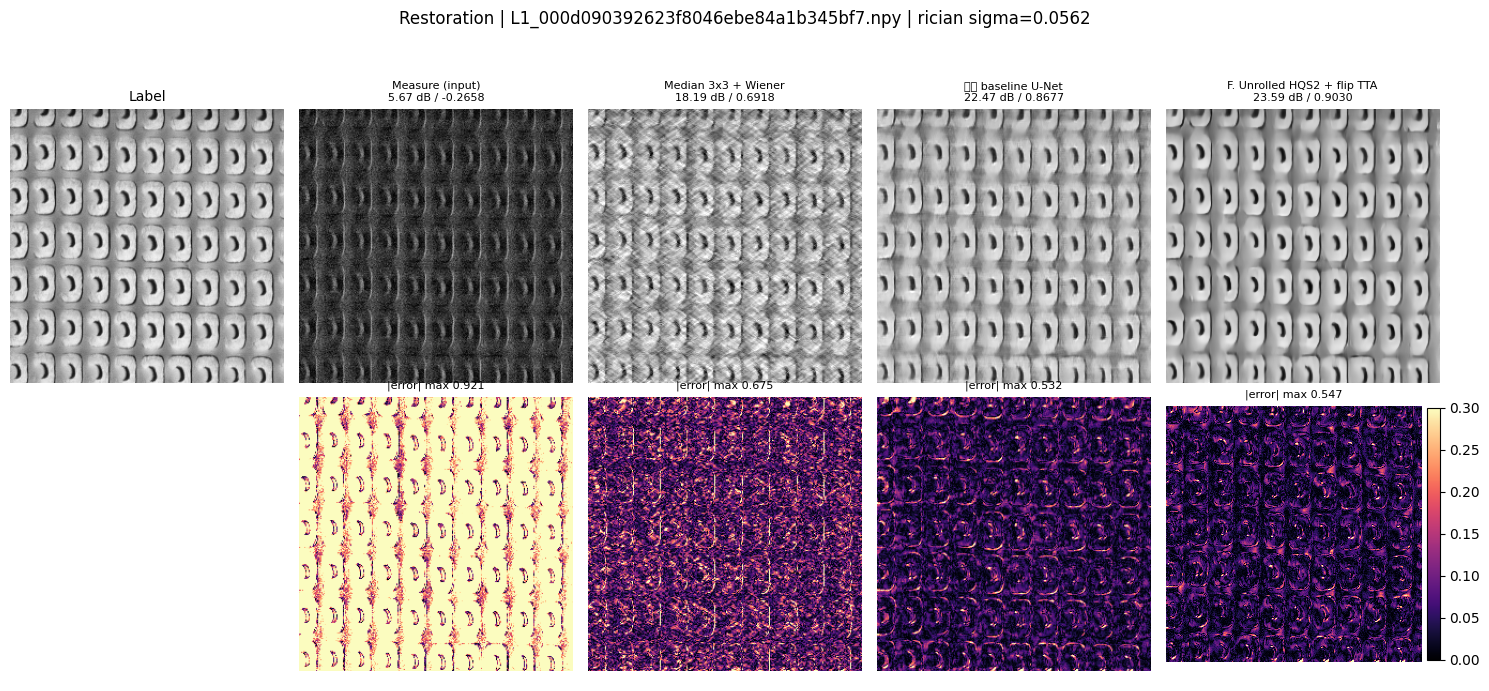

In [32]:
BEST_METHOD = max(METHODS, key=lambda k: float(np.mean([r[f"psnr_{k}"] for r in rows])))
print(f"best method: {METHOD_LABEL[BEST_METHOD]} ({BEST_METHOD})")

SHOW = [m for m in ["measure", "conv_median", "baseline_unet", "iter1_phys_tta", "unrolled9_tta"] if m in METHODS]
SAMPLE_IDX: int = 0

_label, _measure, _blur, _, _nid, _name = test_ds[SAMPLE_IDX]
_lab_t = _label[None].to(config.device)
_mea_t = _measure[None].to(config.device)
with torch.no_grad():
    _preds = all_predict(_mea_t)

lab = _lab_t.cpu().numpy().squeeze()
n_col = 1 + len(SHOW)
fig, axes = plt.subplots(2, n_col, figsize=(3.0 * n_col, 7.0))
axes[0, 0].imshow(lab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Label", fontsize=10)
axes[1, 0].axis("off")
for c, key in enumerate(SHOW):
    img = _preds[key].cpu().numpy().squeeze()
    p = calculate_psnr(_preds[key], _lab_t).item()
    s = calculate_ssim(_preds[key], _lab_t).item()
    err = np.abs(img - lab)
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].set_title(f"{METHOD_LABEL[key]}\n{p:.2f} dB / {s:.4f}", fontsize=8)
    im = axes[1, c + 1].imshow(err, cmap="magma", vmin=0, vmax=0.3)
    axes[1, c + 1].set_title(f"|error| max {err.max():.3f}", fontsize=8)
for ax in axes.flatten():
    ax.axis("off")
fig.colorbar(im, ax=axes[1, -1], fraction=0.046, pad=0.02)
_nt = TEST_NOISE_META.get(_name, {})
fig.suptitle(f"Restoration | {_name} | {_nt.get('noise_type', '?')} sigma={_nt.get('sigma', float('nan')):.4f}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

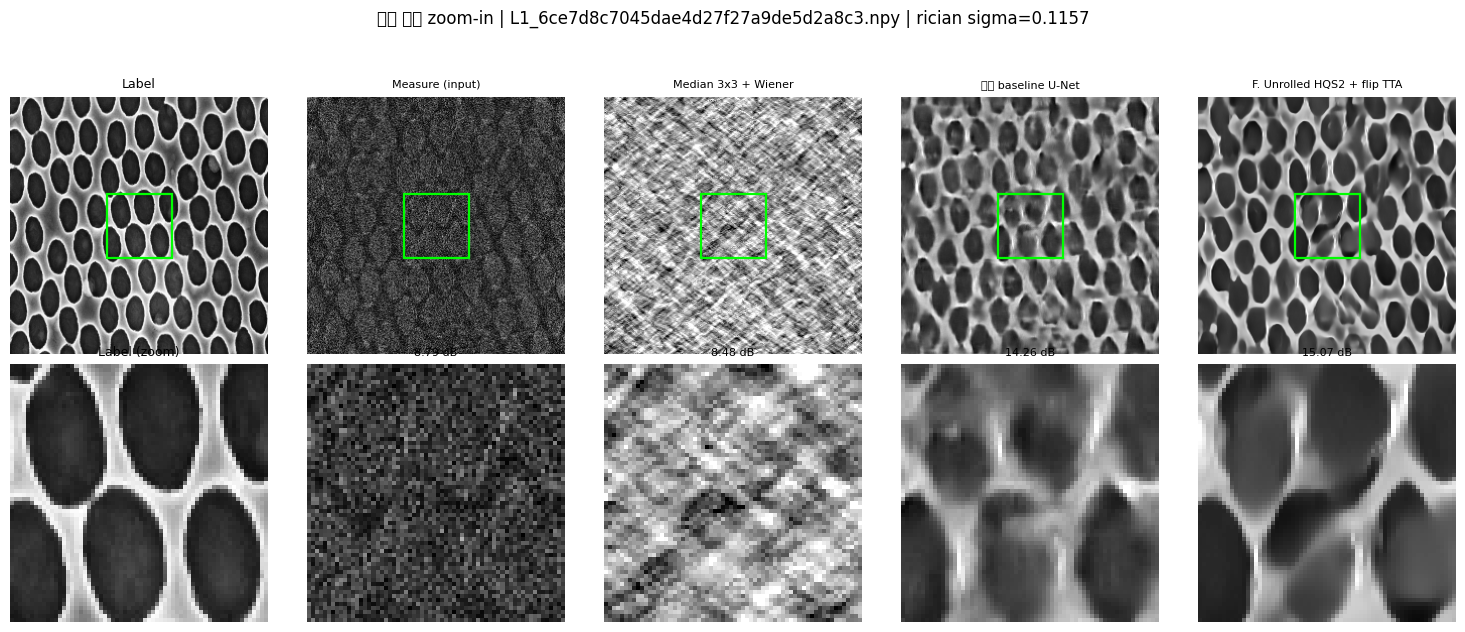

In [33]:
# 가장 어려운 샘플(최저 PSNR)로 zoom-in
_worst = min(range(len(rows)), key=lambda i: rows[i][f"psnr_{BEST_METHOD}"])
_wname = rows[_worst]["file"]
_widx = test_ds.measure.names.index(_wname)
_lb, _me, _, _, _, _ = test_ds[_widx]
_lb_t, _me_t = _lb[None].to(config.device), _me[None].to(config.device)
with torch.no_grad():
    _wp = all_predict(_me_t)
_wlab = _lb_t.cpu().numpy().squeeze()

ZOOM = (96, 96, 64, 64)
r0, c0, hh, ww = ZOOM
fig, axes = plt.subplots(2, 1 + len(SHOW), figsize=(3.0 * (1 + len(SHOW)), 6.4))
axes[0, 0].imshow(_wlab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].add_patch(plt.Rectangle((c0, r0), ww, hh, ec="lime", fc="none", lw=1.6))
axes[0, 0].set_title("Label", fontsize=9)
axes[1, 0].imshow(_wlab[r0 : r0 + hh, c0 : c0 + ww], cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Label (zoom)", fontsize=9)
for c, key in enumerate(SHOW):
    img = _wp[key].cpu().numpy().squeeze()
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].add_patch(plt.Rectangle((c0, r0), ww, hh, ec="lime", fc="none", lw=1.6))
    axes[0, c + 1].set_title(METHOD_LABEL[key], fontsize=8)
    axes[1, c + 1].imshow(img[r0 : r0 + hh, c0 : c0 + ww], cmap="gray", vmin=0, vmax=1)
    axes[1, c + 1].set_title(f"{calculate_psnr(_wp[key], _lb_t).item():.2f} dB", fontsize=8)
for ax in axes.flatten():
    ax.axis("off")
_m = TEST_NOISE_META.get(_wname, {})
fig.suptitle(f"최악 샘플 zoom-in | {_wname} | {_m.get('noise_type','?')} sigma={_m.get('sigma',float('nan')):.4f}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### 11-1. Error map (상대 오차율 %)

`error_map = (I_restored − I_GT) / I_GT × 100`

`I_GT < 0.05` 인 픽셀은 상대오차가 발산하므로 마스킹한다.

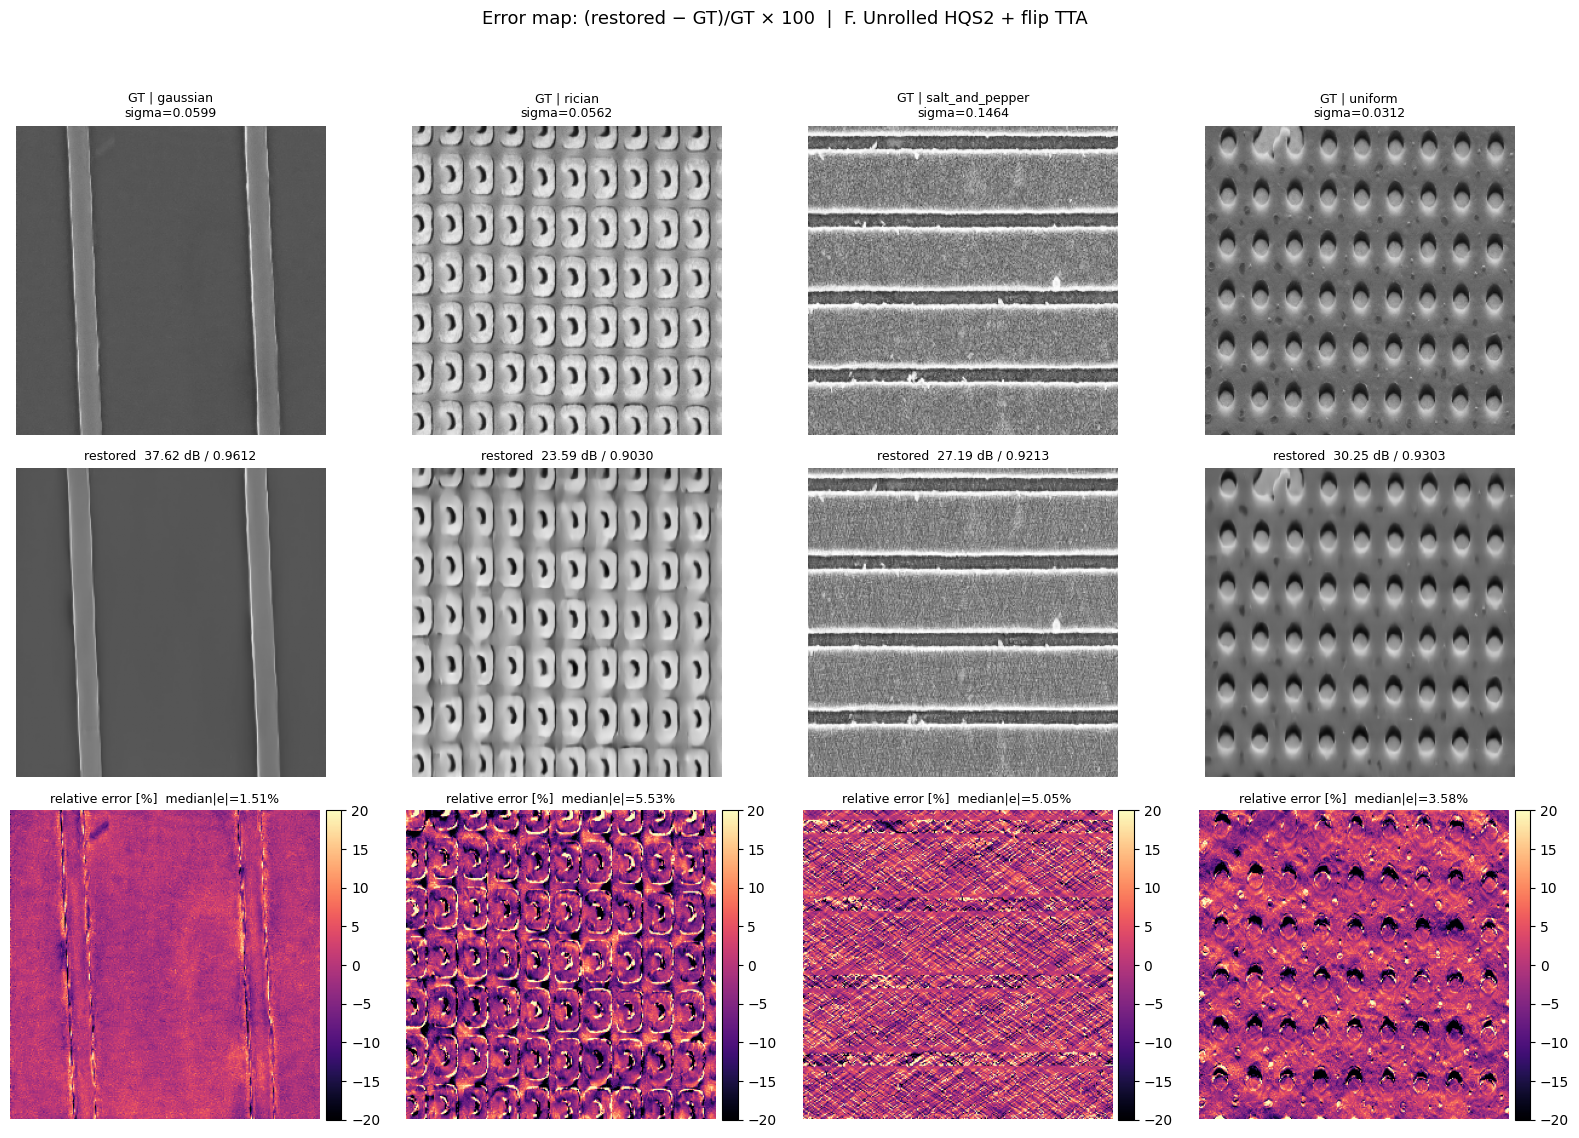

저장: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/error_maps_iter9/error_maps_iter9_unrolled9_tta.png


In [34]:
ERR_DIR = WORK_ROOT / "error_maps_iter9"
ERR_DIR.mkdir(parents=True, exist_ok=True)

_pick: dict[str, int] = {}
for _i in range(len(test_ds)):
    _nm = test_ds.measure.names[_i]
    _t = TEST_NOISE_META.get(_nm, {}).get("noise_type")
    if _t in NOISE_NAMES and _t not in _pick:
        _pick[_t] = _i
    if len(_pick) == len(NOISE_NAMES):
        break

fig, axes = plt.subplots(3, len(_pick), figsize=(4.0 * len(_pick), 11.5))
if len(_pick) == 1:
    axes = axes[:, None]
for c, (_t, _i) in enumerate(sorted(_pick.items())):
    _lb, _me, _, _, _, _nm = test_ds[_i]
    _lb_t, _me_t = _lb[None].to(config.device), _me[None].to(config.device)
    with torch.no_grad():
        _pr = all_predict(_me_t)[BEST_METHOD]
    gt = _lb_t.cpu().numpy().squeeze()
    pr = _pr.cpu().numpy().squeeze()
    rel = np.ma.masked_where(gt < 0.05, (pr - gt) / (gt + 1e-6) * 100.0)

    axes[0, c].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[0, c].set_title(f"GT | {_t}\nsigma={TEST_NOISE_META.get(_nm, {}).get('sigma', float('nan')):.4f}", fontsize=9)
    axes[1, c].imshow(pr, cmap="gray", vmin=0, vmax=1)
    axes[1, c].set_title(f"restored  {calculate_psnr(_pr, _lb_t).item():.2f} dB / {calculate_ssim(_pr, _lb_t).item():.4f}", fontsize=9)
    im = axes[2, c].imshow(rel, cmap="magma", vmin=-20, vmax=20)
    axes[2, c].set_title(f"relative error [%]  median|e|={np.ma.median(np.abs(rel)):.2f}%", fontsize=9)
    plt.colorbar(im, ax=axes[2, c], fraction=0.046, pad=0.02)
    for r in range(3):
        axes[r, c].axis("off")
fig.suptitle(f"Error map: (restored − GT)/GT × 100  |  {METHOD_LABEL[BEST_METHOD]}", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(ERR_DIR / f"error_maps_iter9_{BEST_METHOD}.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"저장: {ERR_DIR / f'error_maps_iter9_{BEST_METHOD}.png'}")

## 12. 취약점 분석 & 요약

In [35]:
_key = BEST_METHOD
print(f"=== {METHOD_LABEL[_key]} ===")
print()
print("[noise type 별]")
for _t in sorted(NOISE_NAMES, key=lambda t: np.mean([r[f"psnr_{_key}"] for r in rows if r["noise_type"] == t])):
    _v = [r[f"psnr_{_key}"] for r in rows if r["noise_type"] == _t]
    _s = [r[f"ssim_{_key}"] for r in rows if r["noise_type"] == _t]
    _in = [r["psnr_measure"] for r in rows if r["noise_type"] == _t]
    print(f"  {_t:<18} PSNR {np.mean(_v):>7.3f} (입력 {np.mean(_in):>6.3f}, 개선 {np.mean(_v) - np.mean(_in):>+6.3f})  SSIM {np.mean(_s):.4f}")

print()
print("[하위 5장]")
for r in sorted(rows, key=lambda r: r[f"psnr_{_key}"])[:5]:
    _m = TEST_NOISE_META.get(r["file"], {})
    print(f"  {r['file'][:32]:<34}{r['noise_type']:<18}sigma={_m.get('sigma', float('nan')):.4f}  PSNR {r[f'psnr_{_key}']:.3f}")
print()
print("[상위 5장]")
for r in sorted(rows, key=lambda r: -r[f"psnr_{_key}"])[:5]:
    _m = TEST_NOISE_META.get(r["file"], {})
    print(f"  {r['file'][:32]:<34}{r['noise_type']:<18}sigma={_m.get('sigma', float('nan')):.4f}  PSNR {r[f'psnr_{_key}']:.3f}")

=== F. Unrolled HQS2 + flip TTA ===

[noise type 별]
  rician             PSNR  22.555 (입력  8.664, 개선 +13.891)  SSIM 0.7640
  uniform            PSNR  28.962 (입력  7.900, 개선 +21.062)  SSIM 0.9162
  gaussian           PSNR  29.732 (입력  8.156, 개선 +21.577)  SSIM 0.8898
  salt_and_pepper    PSNR  33.171 (입력  7.925, 개선 +25.246)  SSIM 0.9733

[하위 5장]
  L1_6ce7d8c7045dae4d27f27a9de5d2a  rician            sigma=0.1157  PSNR 15.066
  L1_3fe6c5543ec41e50b86774f3e6da7  salt_and_pepper   sigma=0.1939  PSNR 15.874
  L1_5bead158cde10dd031880167d2c92  rician            sigma=0.1203  PSNR 17.270
  L1_2dcc564130f9019f9c508d6e85978  rician            sigma=0.1213  PSNR 17.349
  L1_1bd708f6dc494e81343d67e399d59  rician            sigma=0.0918  PSNR 17.441

[상위 5장]
  L1_0df01378473d4629579e6efc2dc3d  uniform           sigma=0.0041  PSNR 42.324
  L1_96578dac7ec11475088527aaf0e32  salt_and_pepper   sigma=0.0239  PSNR 41.592
  L1_2eb653d0a53e4ac65bb6e76729ee6  salt_and_pepper   sigma=0.0609  PSNR 39.860
  L1_1

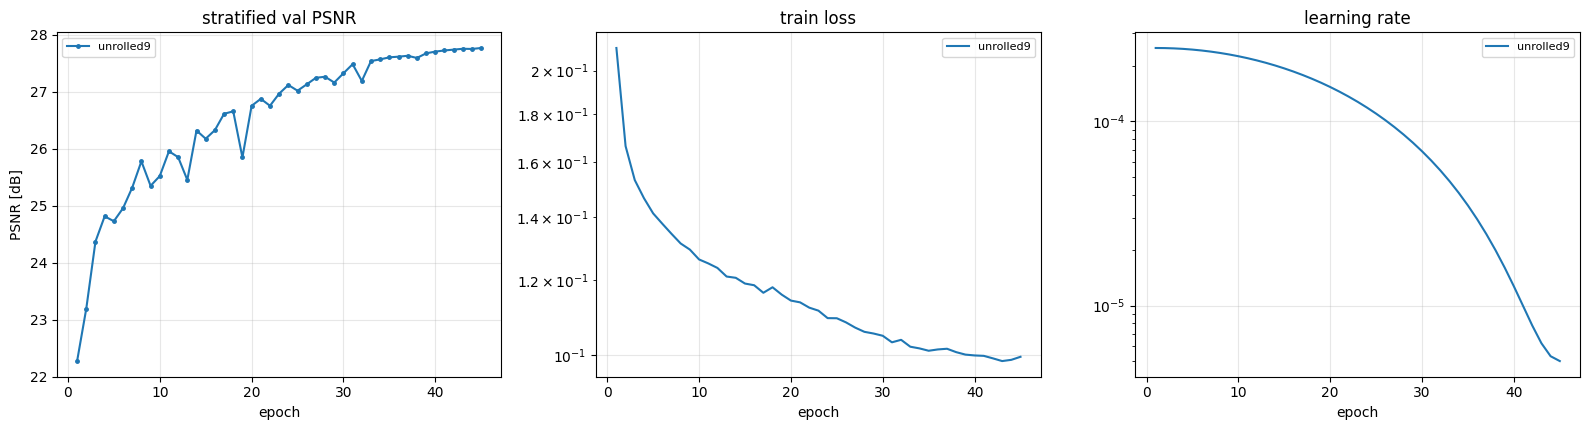


run                 params  best ep   val PSNR  test PSNR  test SSIM
--------------------------------------------------------------------
unrolled9       30,240,200       45     27.764     28.342     0.8830
baseline_unet   13,431,233       -1        nan     25.016     0.8150


In [36]:
if RESULTS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for _k, _r in RESULTS.items():
        _h = [x for x in _r["history"] if "val_psnr" in x]
        if not _h:
            continue
        axes[0].plot([x["epoch"] for x in _h], [x["val_psnr"] for x in _h], marker="o", ms=2.5, label=_k)
        axes[1].plot([x["epoch"] for x in _r["history"]], [x["train_loss"] for x in _r["history"]], label=_k)
        axes[2].plot([x["epoch"] for x in _r["history"]], [x["lr"] for x in _r["history"]], label=_k)
    # iter1 C 의 최종 val 을 수평선으로
    if "iter1_phys" in LOADED and LOADED["iter1_phys"].get("best"):
        _b1 = LOADED["iter1_phys"]["best"].get("psnr")
        if _b1:
            axes[0].axhline(_b1, color="r", ls="--", lw=1, label=f"iter1 C best ({_b1:.2f})")
    axes[0].set_title("stratified val PSNR")
    axes[0].set_ylabel("PSNR [dB]")
    axes[1].set_title("train loss")
    axes[1].set_yscale("log")
    axes[2].set_title("learning rate")
    axes[2].set_yscale("log")
    for a in axes:
        a.set_xlabel("epoch")
        a.grid(alpha=0.3)
        a.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

print()
print(f"{'run':<14}{'params':>12}{'best ep':>9}{'val PSNR':>11}{'test PSNR':>11}{'test SSIM':>11}")
print("-" * 68)
for _k, _r in RESULTS.items():
    _tp = np.mean([r[f"psnr_{_k}"] for r in rows]) if f"psnr_{_k}" in rows[0] else float("nan")
    _ts = np.mean([r[f"ssim_{_k}"] for r in rows]) if f"ssim_{_k}" in rows[0] else float("nan")
    print(f"{_k:<14}{_r['params']:>12,}{_r['best']['epoch']:>9}{_r['best']['psnr']:>11.3f}{_tp:>11.3f}{_ts:>11.4f}")
for _k, _v in LOADED.items():
    _tp = np.mean([r[f"psnr_{_k}"] for r in rows]) if f"psnr_{_k}" in rows[0] else float("nan")
    _ts = np.mean([r[f"ssim_{_k}"] for r in rows]) if f"ssim_{_k}" in rows[0] else float("nan")
    _be = _v.get("best", {}) or {}
    print(f"{_k:<14}{_v['params']:>12,}{_be.get('epoch', -1):>9}{_be.get('psnr', float('nan')):>11.3f}{_tp:>11.3f}{_ts:>11.4f}")

In [37]:
summary = {
    "iter": 9,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "change": ["impulse-cleaned measurement in DC step (tau=1.5)", "Parseval null-cone sigma", "per-stage denoisers", "more steps"],
    "config": {k: str(v) for k, v in asdict(config).items()},
    "best_wiener_K": BEST_K,
    "dncnn_deconv_K": RESULTS.get("dncnn_blur", {}).get("deconv_K"),
    "rule_compliance": {
        "variant_mode": config.variant_mode,
        "noise_realizations_per_clean": config.variant_pool if config.variant_mode == "pool" else "unbounded",
        "augment_flip": config.augment_flip,
        "distinct_corrupted_per_clean": (
            config.variant_pool * (4 if config.augment_flip else 1) if config.variant_mode == "pool" else "unbounded"
        ),
        "limit": RULE_MAX_VARIANTS,
        "strictly_compliant": config.variant_mode == "pool"
        and not config.augment_flip
        and config.variant_pool <= RULE_MAX_VARIANTS,
    },
    "best_method": BEST_METHOD,
    "test": {
        k: {
            "psnr": round(float(np.mean([r[f"psnr_{k}"] for r in rows])), 3),
            "ssim": round(float(np.mean([r[f"ssim_{k}"] for r in rows])), 4),
            "per_noise_psnr": {
                t: round(float(np.mean([r[f"psnr_{k}"] for r in rows if r["noise_type"] == t])), 3)
                for t in NOISE_NAMES
                if any(r["noise_type"] == t for r in rows)
            },
        }
        for k in METHODS
    },
    "paired_vs_iter1": (
        {
            m: {
                (s or "ALL"): {kk: (round(vv, 4) if isinstance(vv, float) else vv) for kk, vv in paired_test(rows, m, "iter1_phys_tta", s).items()}
                for s in [None, *NOISE_NAMES]
            }
            for m in CAND
        }
        if "iter1_phys_tta" in METHODS
        else {}
    ),
    "runs": {
        k: {"run_dir": str(v["run_dir"]), "best": v["best"], "params": v["params"], "spec": v["spec"]}
        for k, v in RESULTS.items()
    },
}
_out = WORK_ROOT / "summary_iter9.json"
_out.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장: {_out}")
print()
print(json.dumps(summary["test"], indent=2, ensure_ascii=False))

저장: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/summary_iter9.json

{
  "measure": {
    "psnr": 8.161,
    "ssim": -0.0143,
    "per_noise_psnr": {
      "gaussian": 8.156,
      "rician": 8.664,
      "uniform": 7.9,
      "salt_and_pepper": 7.925
    }
  },
  "conv_none": {
    "psnr": 15.228,
    "ssim": 0.4146,
    "per_noise_psnr": {
      "gaussian": 15.778,
      "rician": 13.676,
      "uniform": 16.181,
      "salt_and_pepper": 15.276
    }
  },
  "conv_mean": {
    "psnr": 19.256,
    "ssim": 0.5296,
    "per_noise_psnr": {
      "gaussian": 20.393,
      "rician": 16.023,
      "uniform": 20.454,
      "salt_and_pepper": 20.153
    }
  },
  "conv_median": {
    "psnr": 19.288,
    "ssim": 0.5453,
    "per_noise_psnr": {
      "gaussian": 19.485,
      "rician": 15.535,
      "uniform": 18.88,
      "salt_and_pepper": 23.252
    }
  },
  "conv_adaptive": {
    "psnr": 19.088,
    "ssim": 0.5512,
    "per_noise_psnr": {
      "gaussian": 20.519,
      "ric

## 13. 다음 단계

이 노트북의 수치를 보고 판단한다.

| 관측 | 해석 | 조치 |
|---|---|---|
| `unrolled9` > `iter1_phys` 이고 고σ 구간 이득이 큼 | σ 조건부가 의도대로 작동 | 채택. `sigma_gain` / `local_block` 튜닝 |
| 전체는 개선인데 고σ 구간 이득이 없음 | σ̂ 가 정보를 주지 못함 (MAD 과대추정) | σ̂ 추정을 wavelet 기반으로 교체 |
| `unrolled9` ≈ `iter1_phys` (|t| < 2) | σ̂ 채널 무효 또는 `dc_weight` 제거가 상쇄 | `dc_weight` 만 되돌려 분리 검증 |
| `unrolled9` < `iter1_phys` | σ̂ 채널이 방해 | `sigma_gain` 1.0 으로 낮추거나 global 만 사용 |
| `dncnn_blur` 가 `iter1_phys` 에 근접 | 역할 분리 접근도 유효 | **앙상블** (두 출력 평균) 시도 |

### 남은 후보

| # | 항목 | 근거 | 비용 |
|---|---|---|---|
| 1 | **앙상블** (`unrolled9` + `dncnn_blur` 평균) | 서로 다른 구조의 오차는 상관이 낮다 | 10분 |
| 2 | **Unrolled / physics DC step** | 제공 `model_config` 의 `unroll_iters=5`, `phys_dc_steps`, `phys_dc_eta=0.1` 흔적. 역문제에서 표준 SOTA | 4h |
| 3 | Label-free (Noise2Noise) | 가산점. 12개 풀의 같은 noise type 두 실현을 pair 로 | 3h |
| 4 | Rician 부호 복원 | 부호 소실 픽셀이 4.8%. 소규모지만 남은 rician 손실(2.58 dB)의 일부 | 3h |

### 하지 말아야 할 것

- **Rician 2차 모멘트 debias**: 헤더에서 실측으로 역효과 확인
- **epoch 증량**: iter1 에서 ep 49~60 표준편차 0.019 dB 로 수렴 확인
- **ALL 평균만 보고 판단**: noise type 과 σ 구간으로 분해해야 원인이 보인다